In [2]:
## add 10% of gaussian noise to my data 
# x is my training data
# mu is the mean
# std is the standard deviation
import numpy as np
def gaussian_noise(x,mu,std):
    mu=0.0
    std = 0.1 * np.std(x) # for 10% Gaussian noise   
    noise = np.random.normal(mu, std, size = x.shape)
    x_noisy = x + noise
    return x_noisy 

In [3]:
import numpy as np
import pandas as pd
df=pd.read_csv('Base.csv', sep=" ",header=None)
df.columns = [ "Linear", "Polynom2" ,"Polynom3", "Polynom4","Polynom5", "Multilinear" ,"Log" ,"Exp","Sinus"]
df.shape
df.head(10) 

,Linear,Polynom2,Polynom3,Polynom4,Polynom5,Multilinear,Log,Exp,Sinus
0,76.732633,8.186371,0.342075,30.231304,-1.484406,-7.368417,316.752760,7.648365e-22,493.543804
1,-255.779786,147.872945,-119.540557,722.280738,261.191678,50.061044,669.122689,2.110569e-07,-51.729626
2,-181.682230,78.449164,-48.907191,474.553028,132.294141,35.271004,608.601620,1.277567e-10,426.817756
3,146.255741,34.881628,7.129048,171.659264,-24.013077,-21.199785,494.052897,7.315069e-25,337.437942
4,-108.323769,31.352152,-13.797992,223.965642,42.005495,23.797211,522.489524,8.326569e-14,437.638020
5,-173.346025,72.013142,-43.396128,444.487403,119.450459,34.746647,600.487970,5.550687e-11,479.725288
6,-112.438915,33.424232,-15.054492,236.590144,45.617354,27.001242,528.437507,1.256564e-13,497.826501
7,261.320274,121.542714,59.386853,559.161853,-155.113223,-40.355161,629.965396,7.362567e-30,486.842596
8,-287.421536,184.210414,-163.468923,798.099269,312.302780,55.207342,690.264972,4.995549e-06,62.946070
9,-454.986868,443.403286,-579.055442,311.340143,-32.438342,83.228413,775.480874,9.459173e+01,-461.305774


In [4]:
mu=0.0
std = 0.1 * np.std(df) # for 10% Gaussian noise   
df_noisy=gaussian_noise(df,0.0,std)
df_noisy.head(10)

,Linear,Polynom2,Polynom3,Polynom4,Polynom5,Multilinear,Log,Exp,Sinus
0,66.107358,13.750472,-12.277204,94.575053,-20.321508,-4.656863,354.753308,-3.454906,484.930160
1,-285.497480,127.188697,-125.190745,745.800990,250.428570,55.487361,720.266088,2.244424,-153.588769
2,-179.856713,65.752228,-88.201531,462.370872,133.545897,41.358179,558.785526,-2.802639,425.843300
3,111.909176,62.338664,15.520476,115.754275,-15.947397,-17.974897,472.589610,-0.429580,359.017327
4,-60.801890,19.410925,-15.452134,225.247271,51.831650,14.202787,506.988061,1.751968,465.035559
5,-150.988345,77.426856,-71.871500,442.500179,117.107776,25.558462,628.285453,-4.399175,436.211655
6,-118.519213,42.358855,-11.632811,280.225716,33.729545,28.529474,517.629324,-1.286915,473.151424
7,219.485625,119.482609,81.472415,560.293711,-138.399561,-36.465629,611.463559,-0.630022,465.053252
8,-340.592748,169.412454,-164.976702,814.154340,278.215421,50.864412,692.564699,-2.840820,31.593303
9,-460.001430,420.699259,-607.543960,334.955887,-36.249445,87.235861,772.713456,88.321826,-459.430609


In [5]:
## Impor Fakes data
import numpy as np
import pandas as pd
fakes=pd.read_csv('Fakes_data.csv', sep=" ",header=None)
fakes.columns = ["Unif","Cauchy", "Norm", "X1" ,"X2", "X3","X4", "X5","X6"]
fakes.head(10) 

,Unif,Cauchy,Norm,X1,X2,X3,X4,X5,X6
0,-4.873263,-10.586157,0.314718,0.190425,97.531066,-65.414998,-10.395732,-10.081014,-0.634430
1,28.377979,-1.285502,1.200007,0.322401,55.358973,-30.947813,-0.963101,0.236906,-0.497340
2,20.968223,0.843424,-0.807217,0.587166,58.636834,-70.698588,1.430591,0.623374,-0.399758
3,-11.825574,-0.076502,-0.676361,0.826472,1.270350,-66.857857,0.749970,0.073608,0.042764
4,13.632377,0.742583,0.791384,0.528655,94.893771,-76.767901,1.271238,2.062622,0.310674
5,20.134602,-1.531333,0.636765,0.548818,94.896359,-80.572976,-0.982515,-0.345750,-0.535152
6,14.043892,0.849293,-2.390956,0.190869,22.179378,-99.214536,1.040162,-1.350794,-0.387582
7,-23.332027,0.600138,-0.832398,0.547004,76.935112,-36.810102,1.147142,0.314744,-0.273258
8,31.542154,0.190943,-0.566079,0.024617,63.755079,-87.960789,0.215560,-0.350520,-0.002661
9,48.298687,-0.146014,-1.086493,0.335584,10.068955,-45.428491,0.189569,-0.896923,0.053238


In [6]:
####################### Shap avec Linear predict
Y1 = df_noisy['Linear']
X = fakes

In [7]:
##### Random Forest model
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators = 100, random_state = 0)
#Score=cross_val_score(model, X , Y1, cv=10, scoring=make_scorer(mean_squared_error))
#mean_mse, std_mse = np.mean(Score), np.std(Score)
#print(Score)
#print("mean MSE: %.2E, std MSE: %.2E" %(mean_mse, std_mse))
# fit the regressor with x and y data
model.fit(X, Y1) 
#print(model.feature_importances_)


RandomForestRegressor(bootstrap=True, ccp_alpha=0.0, criterion='mse',
                      max_depth=None, max_features='auto', max_leaf_nodes=None,
                      max_samples=None, min_impurity_decrease=0.0,
                      min_impurity_split=None, min_samples_leaf=1,
                      min_samples_split=2, min_weight_fraction_leaf=0.0,
                      n_estimators=100, n_jobs=None, oob_score=False,
                      random_state=0, verbose=0, warm_start=False)

In [8]:
##### SHAP explaination
import shap
shap_values = shap.TreeExplainer(model).shap_values(X)

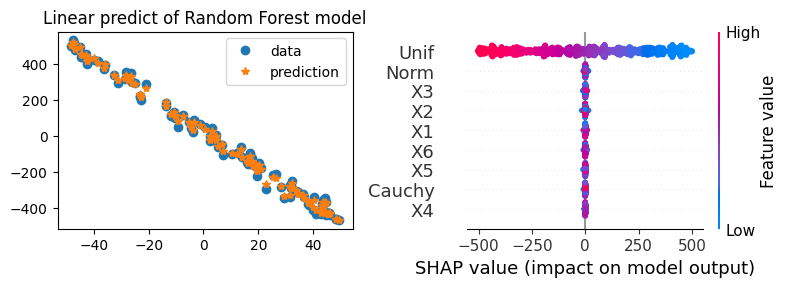

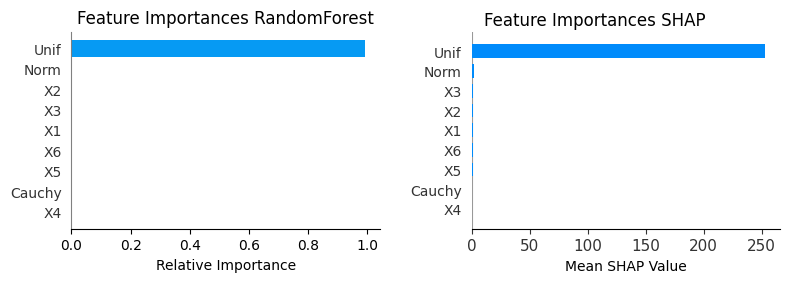

In [10]:
#### Visualisation 
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
plt.subplot(2, 2, 1)
### Visualisation data predict
x=fakes['Unif']
plt.plot (x.iloc[1:100],Y1.iloc[1:100,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(x.iloc[1:100],model.predict(X.iloc[1:100,]) , '*',label="prediction")
plt.title ("Linear predict of Random Forest model") # donne un titre au graphique
plt.legend(loc='upper right')
plt.subplot(2, 2, 2)
shap.summary_plot(shap_values, X)             
## feature importance RandomForest
plt.subplot(2, 2, 3)
features = X.columns
plt.title('Feature Importances RandomForest')
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=10,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=10) 
## feature importance SHAP
plt.subplot(2, 2, 4)
shap.summary_plot(shap_values, X, plot_type="bar",show=0,sort=True)  
plt.xlabel('Mean SHAP Value',fontsize=10)
plt.yticks(fontsize=10,color ='0.2')
plt.suptitle("Feature Importances SHAP",y=0.55,x=0.75)
plt.show()
#plt.savefig("visualinear.jpg",dpi=800, quality=90, optimize=True, progressive=True)

In [11]:
##################### Shap avec Quadratic predict
Y2 = df_noisy['Polynom2']
X = fakes

In [12]:
##### Random Forest model
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators = 100, random_state = 0)
#Score=cross_val_score(model, X , Y2, cv=10, scoring=make_scorer(mean_squared_error))
#mean_mse, std_mse = np.mean(Score), np.std(Score)
#print(Score)
#print("mean MSE: %.2E, std MSE: %.2E" %(mean_mse, std_mse))
# fit the regressor with x and y data
model.fit(X, Y2) 
#print(model.feature_importances_)

RandomForestRegressor(bootstrap=True, ccp_alpha=0.0, criterion='mse',
                      max_depth=None, max_features='auto', max_leaf_nodes=None,
                      max_samples=None, min_impurity_decrease=0.0,
                      min_impurity_split=None, min_samples_leaf=1,
                      min_samples_split=2, min_weight_fraction_leaf=0.0,
                      n_estimators=100, n_jobs=None, oob_score=False,
                      random_state=0, verbose=0, warm_start=False)

In [13]:
##### SHAP explaination
import shap
shap_values = shap.TreeExplainer(model).shap_values(X)

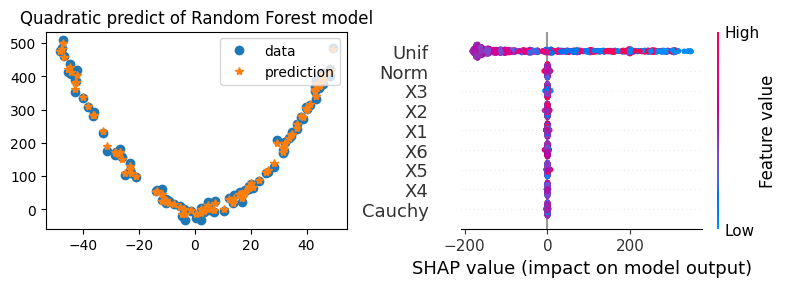

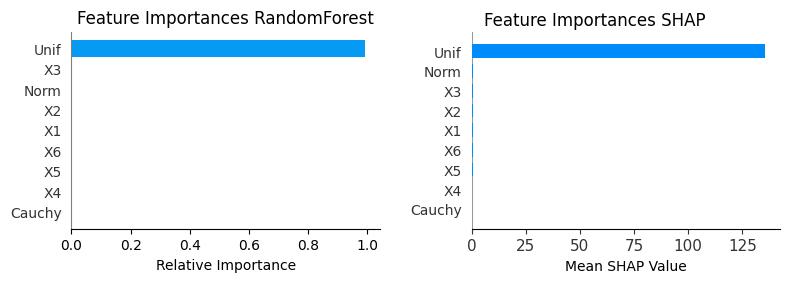

In [15]:
#### Visualisation 
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
plt.subplot(221)
### Visualisation data predict
x=fakes['Unif']
plt.plot (x.iloc[1:100],Y2.iloc[1:100,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(x.iloc[1:100],model.predict(X.iloc[1:100,]) , '*',label="prediction")
plt.title ("Quadratic predict of Random Forest model") # donne un titre au graphique
plt.legend(loc='upper right')
plt.subplot(222)
shap.summary_plot(shap_values, X)
## feature importance RandomForest
plt.subplot(223)
features = X.columns
plt.title('Feature Importances RandomForest')
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=10,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=10)
## feature importance SHAP
plt.subplot(224)
shap.summary_plot(shap_values, X, plot_type="bar",show=0,sort=True)
plt.xlabel('Mean SHAP Value',fontsize=10)
plt.yticks(fontsize=10,color ='0.2')
plt.suptitle("Feature Importances SHAP",y=0.55,x=0.75)
plt.show()
#plt.savefig("visualinear.jpg",dpi=800, quality=90, optimize=True, progressive=True)

In [16]:
############################## Shap avec Cubic predict
Y3 = df_noisy['Polynom3']
X = fakes

In [17]:
##### Random Forest model
model = RandomForestRegressor(n_estimators = 100, random_state = 0)
#Score=cross_val_score(model, X , Y3, cv=10, scoring=make_scorer(mean_squared_error))
#mean_mse, std_mse = np.mean(Score), np.std(Score)
#print(Score)
#print("mean MSE: %.2E, std MSE: %.2E" %(mean_mse, std_mse))
# fit the regressor with x and y data
model.fit(X, Y3) 
#print(model.feature_importances_)


RandomForestRegressor(bootstrap=True, ccp_alpha=0.0, criterion='mse',
                      max_depth=None, max_features='auto', max_leaf_nodes=None,
                      max_samples=None, min_impurity_decrease=0.0,
                      min_impurity_split=None, min_samples_leaf=1,
                      min_samples_split=2, min_weight_fraction_leaf=0.0,
                      n_estimators=100, n_jobs=None, oob_score=False,
                      random_state=0, verbose=0, warm_start=False)

In [19]:
##### SHAP explaination
import shap
shap_values = shap.TreeExplainer(model).shap_values(X)

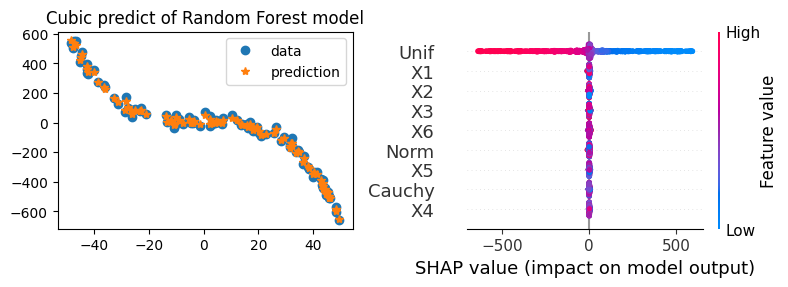

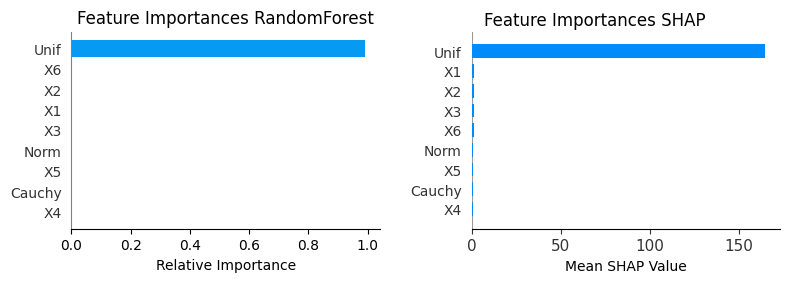

In [20]:
#### Visualisation 
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
plt.subplot(221)
### Visualisation data predict
x=fakes['Unif']
plt.plot (x.iloc[1:100],Y3.iloc[1:100,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(x.iloc[1:100],model.predict(X.iloc[1:100,]) , '*',label="prediction")
plt.title ("Cubic predict of Random Forest model") # donne un titre au graphique
plt.legend(loc='upper right')
plt.subplot(222)
shap.summary_plot(shap_values, X)
## feature importance RandomForest
plt.subplot(223)
features = X.columns
plt.title('Feature Importances RandomForest')
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=10,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=10)
## feature importance SHAP
plt.subplot(224)
shap.summary_plot(shap_values, X, plot_type="bar",show=0,sort=True)
plt.xlabel('Mean SHAP Value',fontsize=10)
plt.yticks(fontsize=10,color ='0.2')
plt.suptitle("Feature Importances SHAP",y=0.55,x=0.75)
plt.show()
#plt.savefig("visualinear.jpg",dpi=800, quality=90, optimize=True, progressive=True)

In [21]:
########################## Shap avec Quartic predict
Y4= df_noisy['Polynom4']
X = fakes

In [22]:
##### Random Forest model
model = RandomForestRegressor(n_estimators = 100, random_state = 0)
#Score=cross_val_score(model, X , Y4, cv=10, scoring=make_scorer(mean_squared_error))
#mean_mse, std_mse = np.mean(Score), np.std(Score)
#print(Score)
#print("mean MSE: %.2E, std MSE: %.2E" %(mean_mse, std_mse))
# fit the regressor with x and y data
model.fit(X, Y4) 
#print(model.feature_importances_)


RandomForestRegressor(bootstrap=True, ccp_alpha=0.0, criterion='mse',
                      max_depth=None, max_features='auto', max_leaf_nodes=None,
                      max_samples=None, min_impurity_decrease=0.0,
                      min_impurity_split=None, min_samples_leaf=1,
                      min_samples_split=2, min_weight_fraction_leaf=0.0,
                      n_estimators=100, n_jobs=None, oob_score=False,
                      random_state=0, verbose=0, warm_start=False)

In [23]:
##### SHAP explaination
import shap
shap_values = shap.TreeExplainer(model).shap_values(X)

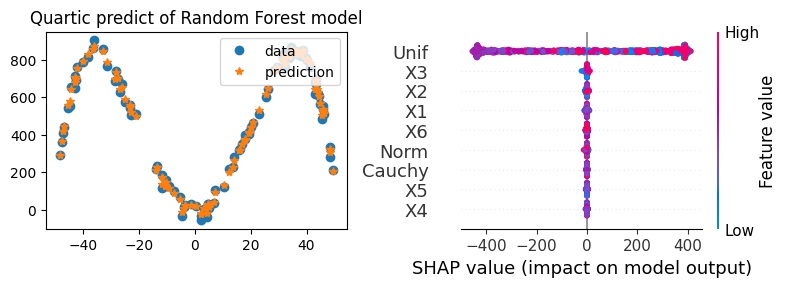

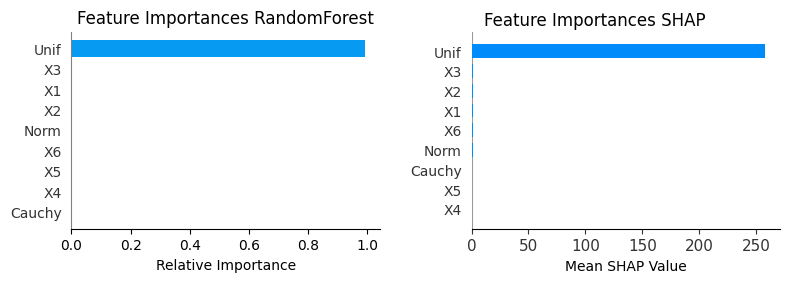

In [24]:
########################################## Visualisation 
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
plt.subplot(221)
### Visualisation data predict
x=fakes['Unif']
plt.plot (x.iloc[1:100],Y4.iloc[1:100,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(x.iloc[1:100],model.predict(X.iloc[1:100,]) , '*',label="prediction")
plt.title ("Quartic predict of Random Forest model") # donne un titre au graphique
plt.legend(loc='upper right')
plt.subplot(222)
shap.summary_plot(shap_values, X)
## feature importance RandomForest
plt.subplot(223)
features = X.columns
plt.title('Feature Importances RandomForest')
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=10,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=10)
## feature importance SHAP
plt.subplot(224)
shap.summary_plot(shap_values, X, plot_type="bar",show=0,sort=True)
plt.xlabel('Mean SHAP Value',fontsize=10)
plt.yticks(fontsize=10,color ='0.2')
plt.suptitle("Feature Importances SHAP",y=0.55,x=0.75)
plt.show()
#plt.savefig("visualinear.jpg",dpi=800, quality=90, optimize=True, progressive=True)

In [25]:
############################## Shap avec Quintic predict
Y5 = df_noisy['Polynom5']
X = fakes

In [26]:
##### Random Forest model
model = RandomForestRegressor(n_estimators = 100, random_state = 0)
#Score=cross_val_score(model, X , Y5, cv=10, scoring=make_scorer(mean_squared_error))
#mean_mse, std_mse = np.mean(Score), np.std(Score)
#print(Score)
#print("mean MSE: %.2E, std MSE: %.2E" %(mean_mse, std_mse))
# fit the regressor with x and y data
model.fit(X, Y5) 
#print(model.feature_importances_)


RandomForestRegressor(bootstrap=True, ccp_alpha=0.0, criterion='mse',
                      max_depth=None, max_features='auto', max_leaf_nodes=None,
                      max_samples=None, min_impurity_decrease=0.0,
                      min_impurity_split=None, min_samples_leaf=1,
                      min_samples_split=2, min_weight_fraction_leaf=0.0,
                      n_estimators=100, n_jobs=None, oob_score=False,
                      random_state=0, verbose=0, warm_start=False)

In [27]:
##### SHAP explaination
import shap
shap_values = shap.TreeExplainer(model).shap_values(X)

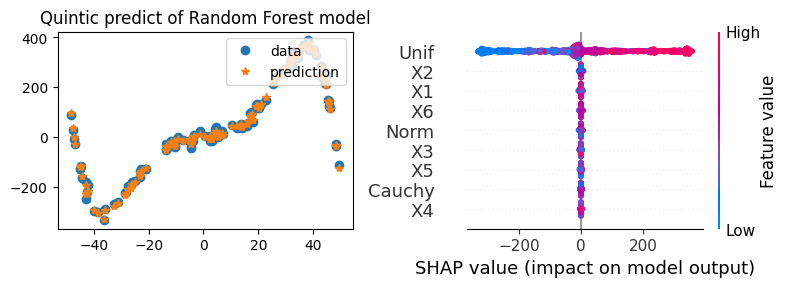

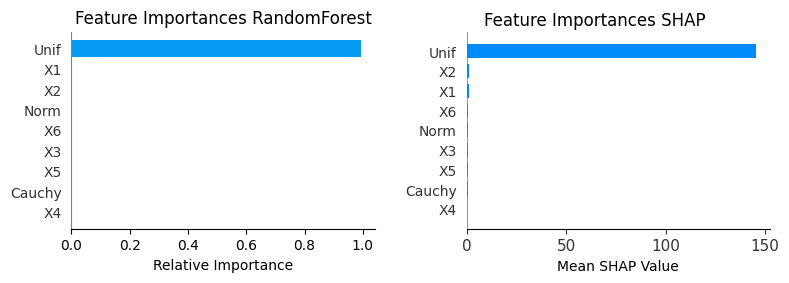

In [28]:
########################################## Visualisation 
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
plt.subplot(2, 2, 1)
### Visualisation data predict
x=fakes['Unif']
plt.plot (x.iloc[1:100],Y5.iloc[1:100,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(x.iloc[1:100],model.predict(X.iloc[1:100,]) , '*',label="prediction")
plt.title ("Quintic predict of Random Forest model") # donne un titre au graphique
plt.legend(loc='upper right')
plt.subplot(2, 2, 2)
shap.summary_plot(shap_values, X)
## feature importance RandomForest
plt.subplot(2, 2, 3)
features = X.columns
plt.title('Feature Importances RandomForest')
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=10,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=10)
## feature importance SHAP
plt.subplot(2, 2, 4)
shap.summary_plot(shap_values, X, plot_type="bar",show=0,sort=True)
plt.xlabel('Mean SHAP Value',fontsize=10)
plt.yticks(fontsize=10,color ='0.2')
plt.suptitle("Feature Importances SHAP",y=0.55,x=0.75)
plt.show()
#plt.savefig("visualinear.jpg",dpi=800, quality=90, optimize=True, progressive=True)

In [29]:
############################## Shap avec Multilinear predict
Y6 = df_noisy['Multilinear']
X = fakes

In [30]:
##### Random Forest model
model = RandomForestRegressor(n_estimators = 100, random_state = 0)
#Score=cross_val_score(model, X , Y6, cv=10, scoring=make_scorer(mean_squared_error))
#mean_mse, std_mse = np.mean(Score), np.std(Score)
#print(Score)
#print("mean MSE: %.2E, std MSE: %.2E" %(mean_mse, std_mse))
# fit the regressor with x and y data
model.fit(X, Y6) 
#print(model.feature_importances_)


RandomForestRegressor(bootstrap=True, ccp_alpha=0.0, criterion='mse',
                      max_depth=None, max_features='auto', max_leaf_nodes=None,
                      max_samples=None, min_impurity_decrease=0.0,
                      min_impurity_split=None, min_samples_leaf=1,
                      min_samples_split=2, min_weight_fraction_leaf=0.0,
                      n_estimators=100, n_jobs=None, oob_score=False,
                      random_state=0, verbose=0, warm_start=False)

In [31]:
##### SHAP explaination
import shap
shap_values = shap.TreeExplainer(model).shap_values(X)

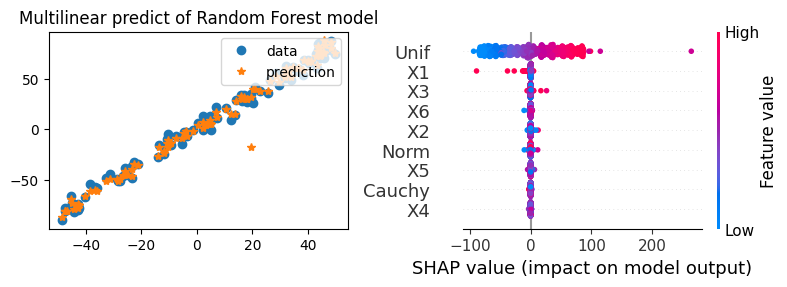

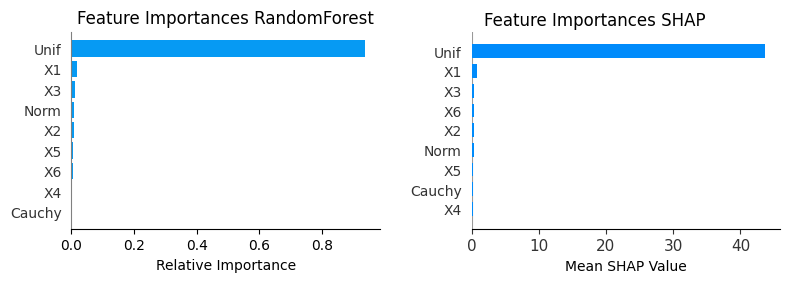

In [33]:
########################################## Visualisation 
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
plt.subplot(221)
### Visualisation data predict
x=fakes['Unif']
plt.plot (x.iloc[1:100],Y6.iloc[1:100,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(x.iloc[1:100],model.predict(X.iloc[1:100,]) , '*',label="prediction")
plt.title ("Multilinear predict of Random Forest model") # donne un titre au graphique
plt.legend(loc='upper right')
plt.subplot(222)
shap.summary_plot(shap_values, X)
## feature importance RandomForest
plt.subplot(223)
features = X.columns
plt.title('Feature Importances RandomForest')
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=10,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=10)
## feature importance SHAP
plt.subplot(224)
shap.summary_plot(shap_values, X, plot_type="bar",show=0,sort=True)
plt.xlabel('Mean SHAP Value',fontsize=10)
plt.yticks(fontsize=10,color ='0.2')
plt.suptitle("Feature Importances SHAP",y=0.55,x=0.75)
plt.show()
#plt.savefig("visualinear.jpg",dpi=800, quality=90, optimize=True, progressive=True)

In [34]:
############################## Shap avec Logarithme predict
Y7 = df_noisy['Log']
X = fakes

In [35]:
##### Random Forest model
model = RandomForestRegressor(n_estimators = 100, random_state = 0)
#Score=cross_val_score(model, X , Y7, cv=10, scoring=make_scorer(mean_squared_error))
#mean_mse, std_mse = np.mean(Score), np.std(Score)
#print(Score)
#print("mean MSE: %.2E, std MSE: %.2E" %(mean_mse, std_mse))
# fit the regressor with x and y data
model.fit(X, Y7) 
#print(model.feature_importances_)


RandomForestRegressor(bootstrap=True, ccp_alpha=0.0, criterion='mse',
                      max_depth=None, max_features='auto', max_leaf_nodes=None,
                      max_samples=None, min_impurity_decrease=0.0,
                      min_impurity_split=None, min_samples_leaf=1,
                      min_samples_split=2, min_weight_fraction_leaf=0.0,
                      n_estimators=100, n_jobs=None, oob_score=False,
                      random_state=0, verbose=0, warm_start=False)

In [36]:
##### SHAP explaination
import shap
shap_values = shap.TreeExplainer(model).shap_values(X)

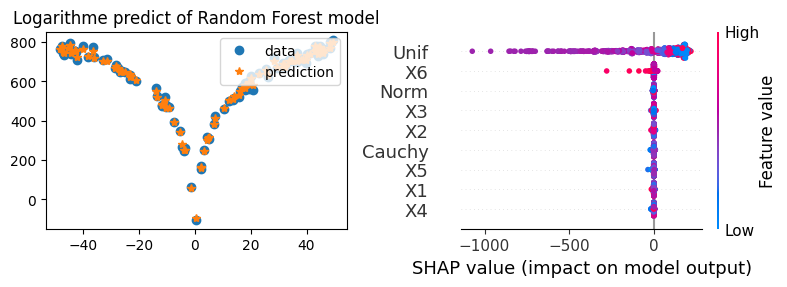

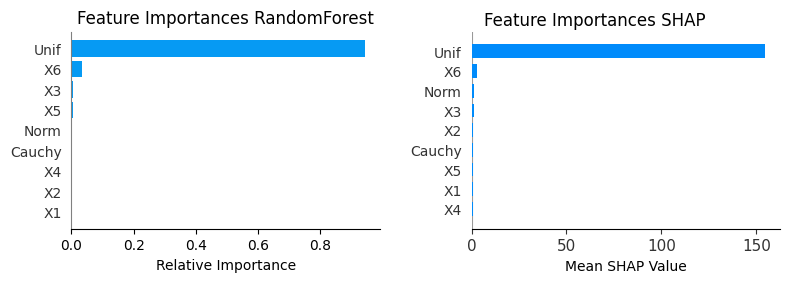

In [37]:
########################################## Visualisation 
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
plt.subplot(2, 2, 1)
### Visualisation data predict
x=fakes['Unif']
plt.plot (x.iloc[1:100],Y7.iloc[1:100,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(x.iloc[1:100],model.predict(X.iloc[1:100,]) , '*',label="prediction")
plt.title ("Logarithme predict of Random Forest model") # donne un titre au graphique
plt.legend(loc='upper right')
plt.subplot(2, 2, 2)
shap.summary_plot(shap_values, X)
## feature importance RandomForest
plt.subplot(2, 2, 3)
features = X.columns
plt.title('Feature Importances RandomForest')
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=10,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=10)
## feature importance SHAP
plt.subplot(2, 2, 4)
shap.summary_plot(shap_values, X, plot_type="bar",show=0,sort=True)
plt.xlabel('Mean SHAP Value',fontsize=10)
plt.yticks(fontsize=10,color ='0.2')
plt.suptitle("Feature Importances SHAP",y=0.55,x=0.75)
plt.show()
#plt.savefig("visualinear.jpg",dpi=800, quality=90, optimize=True, progressive=True)

In [38]:
############################## Shap avec Exponentiel predict
Y8 = df_noisy['Exp']
X = fakes

In [39]:
##### Random Forest model
model = RandomForestRegressor(n_estimators = 100, random_state = 0)
Score=cross_val_score(model, X , Y8, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
print(Score)
print("mean MSE: %.2E, std MSE: %.2E" %(mean_mse, std_mse))
# fit the regressor with x and y data
model.fit(X, Y8) 
print(model.feature_importances_)


[ 13.3275831   37.07335625  76.97775689  23.2536709   15.42177999
  19.77753041  14.90823476  82.31137437  12.64868407 143.98452999]
mean MSE: 4.40E+01, std MSE: 4.15E+01
[0.97003109 0.00352989 0.00217249 0.00415303 0.00432364 0.00287116
 0.00351189 0.00552665 0.00388018]


In [40]:
##### SHAP explaination
import shap
shap_values = shap.TreeExplainer(model).shap_values(X)

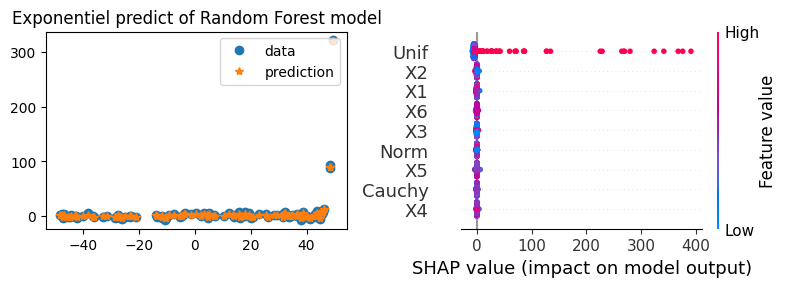

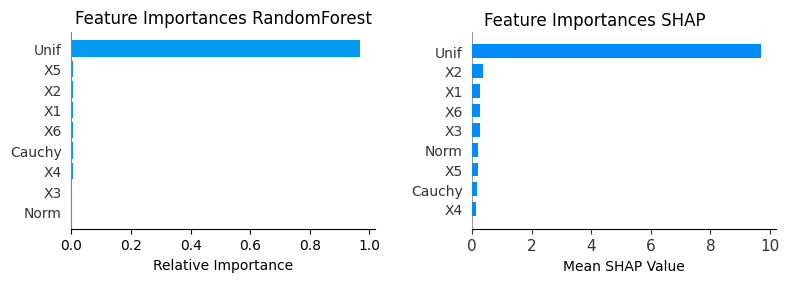

In [41]:
########################################## Visualisation 
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
plt.subplot(2, 2, 1)
### Visualisation data predict
x=fakes['Unif']
plt.plot (x.iloc[1:100],Y8.iloc[1:100,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(x.iloc[1:100],model.predict(X.iloc[1:100,]) , '*',label="prediction")
plt.title ("Exponentiel predict of Random Forest model") # donne un titre au graphique
plt.legend(loc='upper right')
plt.subplot(2, 2, 2)
shap.summary_plot(shap_values, X)
## feature importance RandomForest
plt.subplot(2, 2, 3)
features = X.columns
plt.title('Feature Importances RandomForest')
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=10,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=10)
## feature importance SHAP
plt.subplot(2, 2, 4)
shap.summary_plot(shap_values, X, plot_type="bar",show=0,sort=True)
plt.xlabel('Mean SHAP Value',fontsize=10)
plt.yticks(fontsize=10,color ='0.2')
plt.suptitle("Feature Importances SHAP",y=0.55,x=0.75)
plt.show()
#plt.savefig("visualinear.jpg",dpi=800, quality=90, optimize=True, progressive=True)

In [42]:
############################## Shap avec Sinus predict
Y9 = df_noisy['Sinus']
X = fakes

In [43]:
##### Random Forest model
model = RandomForestRegressor(n_estimators = 100, random_state = 0)
Score=cross_val_score(model, X , Y9, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
print(Score)
print("mean MSE: %.2E, std MSE: %.2E" %(mean_mse, std_mse))
# fit the regressor with x and y data
model.fit(X, Y9) 
#print(model.feature_importances_)


[57962.32293048 62433.47802177 41735.77202258 43776.81621404
 41001.54432163 50181.99204824 29932.19182283 45291.80923961
 52006.47926982 43816.9118373 ]
mean MSE: 4.68E+04, std MSE: 8.78E+03


RandomForestRegressor(bootstrap=True, ccp_alpha=0.0, criterion='mse',
                      max_depth=None, max_features='auto', max_leaf_nodes=None,
                      max_samples=None, min_impurity_decrease=0.0,
                      min_impurity_split=None, min_samples_leaf=1,
                      min_samples_split=2, min_weight_fraction_leaf=0.0,
                      n_estimators=100, n_jobs=None, oob_score=False,
                      random_state=0, verbose=0, warm_start=False)

In [44]:
##### SHAP explaination
import shap
shap_values = shap.TreeExplainer(model).shap_values(X)

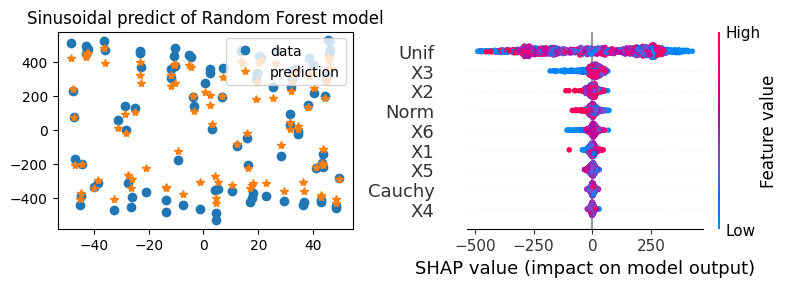

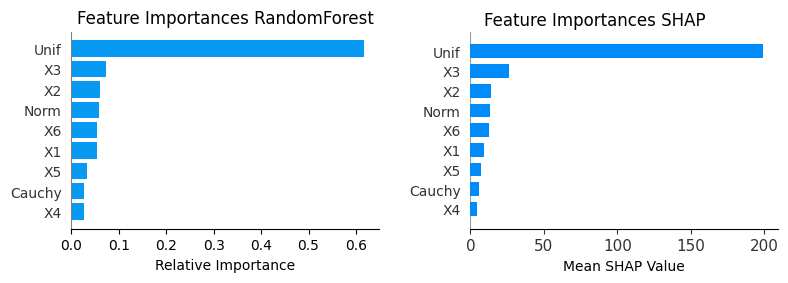

In [45]:
########################################## Visualisation 
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
plt.subplot(2, 2, 1)
### Visualisation data predict
x=fakes['Unif']
plt.plot (x.iloc[1:100],Y9.iloc[1:100,],'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(x.iloc[1:100],model.predict(X.iloc[1:100,]) , '*',label="prediction")
plt.title ("Sinusoidal predict of Random Forest model") # donne un titre au graphique
plt.legend(loc='upper right')
plt.subplot(2, 2, 2)
shap.summary_plot(shap_values, X)
## feature importance RandomForest
plt.subplot(2, 2, 3)
features = X.columns
plt.title('Feature Importances RandomForest')
plt.barh(range(len(indices)), importances[indices], color='#069AF3',align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=10,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=10)
plt.subplot(2, 2, 4)
shap.summary_plot(shap_values, X, plot_type="bar",show=0,sort=True)
plt.xlabel('Mean SHAP Value',fontsize=10)
plt.yticks(fontsize=10,color ='0.2')
plt.suptitle("Feature Importances SHAP",y=0.55,x=0.75)
plt.show()
#plt.savefig("visualinear.jpg",dpi=800, quality=90, optimize=True, progressive=True)

In [47]:
## add 50% of gaussian noise to my data 
# x is my training data
# mu is the mean
# std is the standard deviation
import numpy as np
def gaussian_noise(x,mu,std):
    mu=0.0
    std = 0.5 * np.std(x) # for 50% Gaussian noise   
    noise = np.random.normal(mu, std, size = x.shape)
    x_noisy = x + noise
    return x_noisy 

In [48]:
mu=0.0
std = 0.5 * np.std(df) # for 50% Gaussian noise   
df_noisy_50=gaussian_noise(df,0.0,std)
df_noisy_50.head(10)

,Linear,Polynom2,Polynom3,Polynom4,Polynom5,Multilinear,Log,Exp,Sinus
0,97.489610,17.113761,137.825038,148.008153,106.927465,4.696430,161.982514,-2.194382,931.475931
1,-424.473570,201.866732,55.934683,731.675161,189.654699,23.506658,515.307858,-19.136504,-201.272421
2,-166.193969,-36.647470,-116.906702,518.379215,181.998492,42.225777,591.319310,17.833526,492.446708
3,60.129342,145.383447,176.413589,231.501862,102.654075,16.644182,369.396931,-20.518083,212.462156
4,176.061784,-44.136665,106.382776,242.616127,127.142680,27.887904,595.920879,23.145123,492.615641
5,-392.744122,2.609269,-152.971587,702.804878,118.150618,-1.653112,452.068770,20.085974,720.433422
6,55.735488,131.140010,-48.445670,120.529349,-45.818539,11.126619,415.703008,-18.782185,783.325969
7,168.229394,184.315039,101.774751,508.264794,-51.693433,-56.945666,633.813496,6.193170,591.008116
8,-152.879394,111.368424,-181.200987,735.035256,315.740193,38.113071,764.204503,-18.755865,-219.612771
9,-317.532951,582.407059,-726.043719,294.358707,57.089375,21.329203,740.082804,78.893529,-653.194054


In [49]:
####################### Shap avec Linear predict
Y1 = df_noisy_50['Linear']
X = fakes

In [50]:
##### Random Forest model
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators = 100, random_state = 0)
Score=cross_val_score(model, X , Y1, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
print(Score)
print("mean MSE: %.2E, std MSE: %.2E" %(mean_mse, std_mse))
# fit the regressor with x and y data
model.fit(X, Y1) 
print(model.feature_importances_)


[33803.85751616 17755.00298866 30754.67871765 24177.61084692
 20216.83791886 24397.40329773 17587.57226432 25873.64333085
 30496.43688039 26122.75105023]
mean MSE: 2.51E+04, std MSE: 5.24E+03
[0.81697637 0.01575456 0.02786964 0.02793493 0.02684755 0.02558125
 0.01646191 0.0172688  0.02530499]


In [51]:
##### SHAP explaination
import shap
shap_values = shap.TreeExplainer(model).shap_values(X)

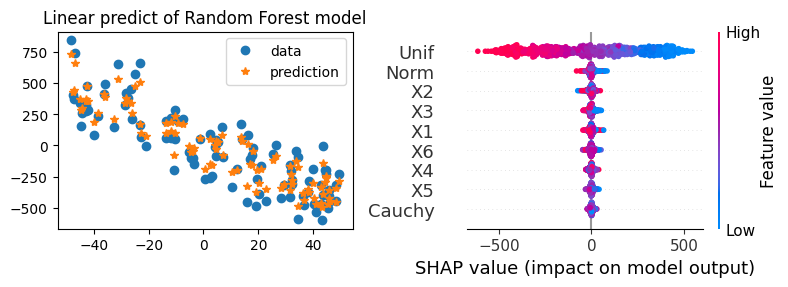

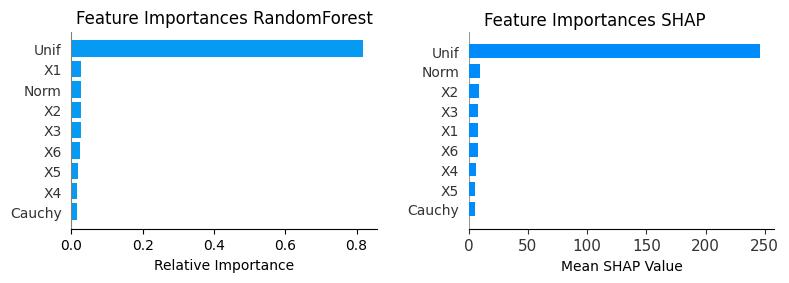

In [52]:
#### Visualisation 
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
plt.subplot(2, 2, 1)
### Visualisation data predict
x=fakes['Unif']
plt.plot (x.iloc[1:100],Y1.iloc[1:100,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(x.iloc[1:100],model.predict(X.iloc[1:100,]) , '*',label="prediction")
plt.title ("Linear predict of Random Forest model") # donne un titre au graphique
plt.legend(loc='upper right')
plt.subplot(2, 2, 2)
shap.summary_plot(shap_values, X)             
## feature importance RandomForest
plt.subplot(2, 2, 3)
features = X.columns
plt.title('Feature Importances RandomForest')
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=10,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=10) 
## feature importance SHAP
plt.subplot(2, 2, 4)
shap.summary_plot(shap_values, X, plot_type="bar",show=0,sort=True) 
plt.xlabel('Mean SHAP Value',fontsize=10)
plt.yticks(fontsize=10,color ='0.2')
plt.suptitle("Feature Importances SHAP",y=0.55,x=0.75)
plt.show()
#plt.savefig("visualinear.jpg",dpi=800, quality=90, optimize=True, progressive=True)

In [53]:
##################### Shap avec Quadratic predict
Y2 = df_noisy_50['Polynom2']
X = fakes

In [54]:
##### Random Forest model
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators = 100, random_state = 0)
Score=cross_val_score(model, X , Y2, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
print(Score)
print("mean MSE: %.2E, std MSE: %.2E" %(mean_mse, std_mse))
# fit the regressor with x and y data
model.fit(X, Y2) 
print(model.feature_importances_)

[7347.34345717 6205.21063054 7934.19294499 6820.65428378 7720.67604728
 6370.54611902 6175.94657319 6557.93807039 7858.27741538 8115.69701546]
mean MSE: 7.11E+03, std MSE: 7.28E+02
[0.83286274 0.01222325 0.02199461 0.02788609 0.02655619 0.02726576
 0.01242462 0.01420958 0.02457716]


In [55]:
##### SHAP explaination
import shap
shap_values = shap.TreeExplainer(model).shap_values(X)

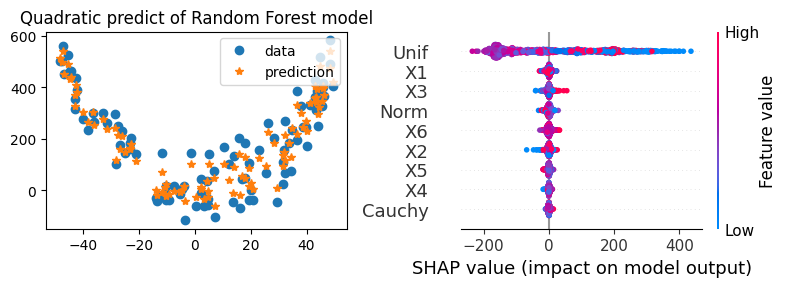

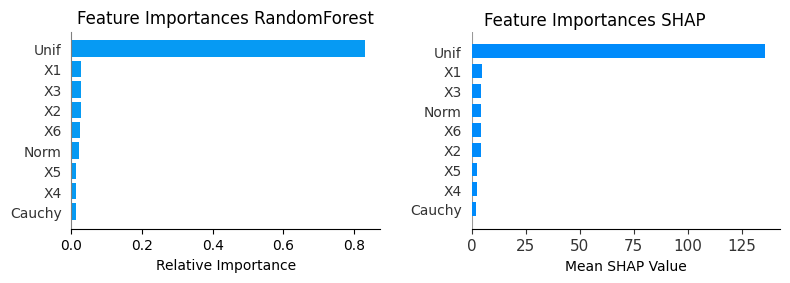

In [56]:
#### Visualisation 
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
plt.subplot(2, 2, 1)
### Visualisation data predict
x=fakes['Unif']
plt.plot (x.iloc[1:100],Y2.iloc[1:100,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(x.iloc[1:100],model.predict(X.iloc[1:100,]) , '*',label="prediction")
plt.title ("Quadratic predict of Random Forest model") # donne un titre au graphique
plt.legend(loc='upper right')
plt.subplot(2, 2, 2)
shap.summary_plot(shap_values, X)
## feature importance RandomForest
plt.subplot(2, 2, 3)
features = X.columns
plt.title('Feature Importances RandomForest')
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=10,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=10)
## feature importance SHAP
plt.subplot(2, 2, 4)
shap.summary_plot(shap_values, X, plot_type="bar",show=0,sort=True)
plt.xlabel('Mean SHAP Value',fontsize=10)
plt.yticks(fontsize=10,color ='0.2')
plt.suptitle("Feature Importances SHAP",y=0.55,x=0.75)
plt.show()
#plt.savefig("visualinear.jpg",dpi=800, quality=90, optimize=True, progressive=True)

In [57]:
############################## Shap avec Cubic predict
Y3 = df_noisy_50['Polynom3']
X = fakes

In [58]:
##### Random Forest model
model = RandomForestRegressor(n_estimators = 100, random_state = 0)
Score=cross_val_score(model, X , Y3, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
print(Score)
print("mean MSE: %.2E, std MSE: %.2E" %(mean_mse, std_mse))
# fit the regressor with x and y data
model.fit(X, Y3) 
print(model.feature_importances_)


[20511.97308311 14124.78840962 13492.70744074 18486.92552262
 18771.48669251 14266.62676613 21636.80761514 21227.98359696
 13693.45445305 20017.28939725]
mean MSE: 1.76E+04, std MSE: 3.18E+03
[0.8306758  0.0177451  0.02223229 0.0249353  0.02477374 0.02394365
 0.01609515 0.01709589 0.02250309]


In [59]:
##### SHAP explaination
import shap
shap_values = shap.TreeExplainer(model).shap_values(X)

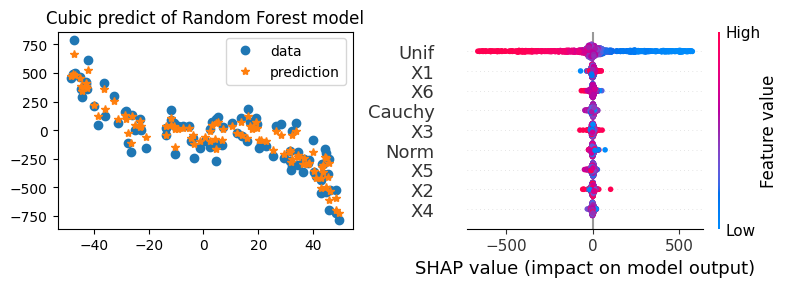

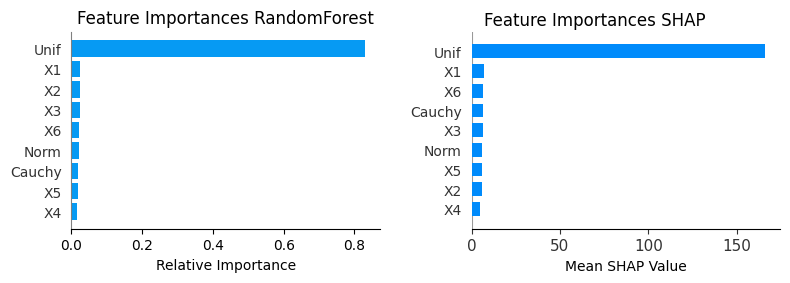

In [60]:
#### Visualisation 
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
plt.subplot(2, 2, 1)
### Visualisation data predict
x=fakes['Unif']
plt.plot (x.iloc[1:100],Y3.iloc[1:100,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(x.iloc[1:100],model.predict(X.iloc[1:100,]) , '*',label="prediction")
plt.title ("Cubic predict of Random Forest model") # donne un titre au graphique
plt.legend(loc='upper right')
plt.subplot(2, 2, 2)
shap.summary_plot(shap_values, X)
## feature importance RandomForest
plt.subplot(2, 2, 3)
features = X.columns
plt.title('Feature Importances RandomForest')
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=10,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=10)
## feature importance SHAP
plt.subplot(2, 2, 4)
shap.summary_plot(shap_values, X, plot_type="bar",show=0,sort=True)
plt.xlabel('Mean SHAP Value',fontsize=10)
plt.yticks(fontsize=10,color ='0.2')
plt.suptitle("Feature Importances SHAP",y=0.55,x=0.75)
plt.show()
#plt.savefig("visualinear.jpg",dpi=800, quality=90, optimize=True, progressive=True)

In [61]:
########################## Shap avec Quartic predict
Y4= df_noisy_50['Polynom4']
X = fakes

In [62]:
##### Random Forest model
model = RandomForestRegressor(n_estimators = 100, random_state = 0)
Score=cross_val_score(model, X , Y4, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
print(Score)
print("mean MSE: %.2E, std MSE: %.2E" %(mean_mse, std_mse))
# fit the regressor with x and y data
model.fit(X, Y4) 
print(model.feature_importances_)


[23150.98891056 27834.179044   31137.73947045 28978.06171313
 29293.61592811 26359.7502302  20252.94752815 23724.89827399
 25160.07691249 27245.35982017]
mean MSE: 2.63E+04, std MSE: 3.12E+03
[0.84312016 0.01348409 0.02002826 0.02367144 0.02289564 0.02533488
 0.01264079 0.01733724 0.0214875 ]


In [63]:
##### SHAP explaination
import shap
shap_values = shap.TreeExplainer(model).shap_values(X)

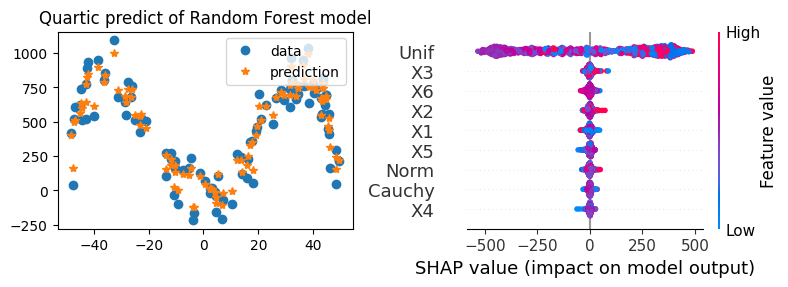

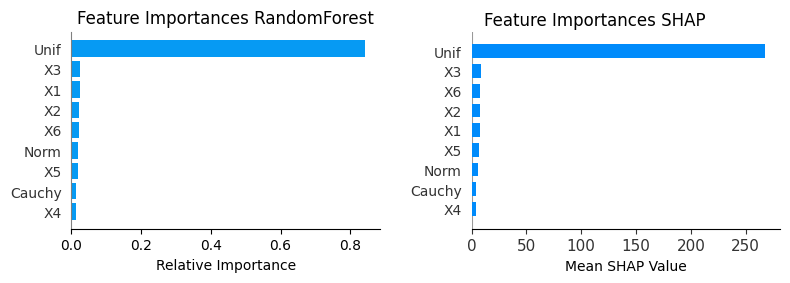

In [64]:
########################################## Visualisation 
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
plt.subplot(2, 2, 1)
### Visualisation data predict
x=fakes['Unif']
plt.plot (x.iloc[1:100],Y4.iloc[1:100,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(x.iloc[1:100],model.predict(X.iloc[1:100,]) , '*',label="prediction")
plt.title ("Quartic predict of Random Forest model") # donne un titre au graphique
plt.legend(loc='upper right')
plt.subplot(2, 2, 2)
shap.summary_plot(shap_values, X)
## feature importance RandomForest
plt.subplot(2, 2, 3)
features = X.columns
plt.title('Feature Importances RandomForest')
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=10,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=10)
## feature importance SHAP
plt.subplot(2, 2, 4)
shap.summary_plot(shap_values, X, plot_type="bar",show=0,sort=True)
plt.xlabel('Mean SHAP Value',fontsize=10)
plt.yticks(fontsize=10,color ='0.2')
plt.suptitle("Feature Importances SHAP",y=0.55,x=0.75)
plt.show()
#plt.savefig("visualinear.jpg",dpi=800, quality=90, optimize=True, progressive=True)

In [74]:
############################## Shap avec Quintic predict
Y5 = df_noisy_50['Polynom5']
X = fakes

In [75]:
##### Random Forest model
model = RandomForestRegressor(n_estimators = 100, random_state = 0)
Score=cross_val_score(model, X , Y5, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
print(Score)
print("mean MSE: %.2E, std MSE: %.2E" %(mean_mse, std_mse))
# fit the regressor with x and y data
model.fit(X, Y5) 
print(model.feature_importances_)


[ 9887.2024269   9177.57661714 10668.41840874  8597.31895022
  8532.95254779  9911.09742028 10547.3812224   8636.01396505
  9863.80426825  8940.98247808]
mean MSE: 9.48E+03, std MSE: 7.63E+02
[0.84593809 0.01253517 0.01932298 0.02550474 0.02693172 0.02497993
 0.01207829 0.01319206 0.01951703]


In [76]:
##### SHAP explaination
import shap
shap_values = shap.TreeExplainer(model).shap_values(X)

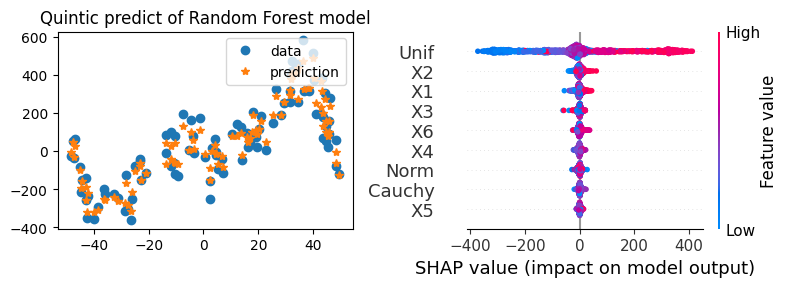

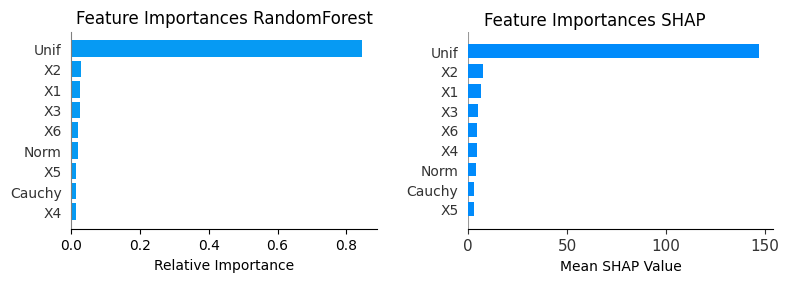

In [77]:
########################################## Visualisation 
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
plt.subplot(2, 2, 1)
### Visualisation data predict
x=fakes['Unif']
plt.plot (x.iloc[1:100],Y5.iloc[1:100,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(x.iloc[1:100],model.predict(X.iloc[1:100,]) , '*',label="prediction")
plt.title ("Quintic predict of Random Forest model") # donne un titre au graphique
plt.legend(loc='upper right')
plt.subplot(2, 2, 2)
shap.summary_plot(shap_values, X)
## feature importance RandomForest
plt.subplot(2, 2, 3)
features = X.columns
plt.title('Feature Importances RandomForest')
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=10,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=10)
## feature importance SHAP
plt.subplot(224)
shap.summary_plot(shap_values, X, plot_type="bar",show=0,sort=True)
plt.xlabel('Mean SHAP Value',fontsize=10)
plt.yticks(fontsize=10,color ='0.2')
plt.suptitle("Feature Importances SHAP",y=0.55,x=0.75)
plt.show()
#plt.savefig("visualinear.jpg",dpi=800, quality=90, optimize=True, progressive=True)

In [69]:
############################## Shap avec Multilinear predict
Y6 = df_noisy_50['Multilinear']
X = fakes

In [70]:
##### Random Forest model
model = RandomForestRegressor(n_estimators = 100, random_state = 0)
Score=cross_val_score(model, X , Y6, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
print(Score)
print("mean MSE: %.2E, std MSE: %.2E" %(mean_mse, std_mse))
# fit the regressor with x and y data
model.fit(X, Y6) 
print(model.feature_importances_)


[1105.72149474  995.9140134  1016.82183191 3364.20868589  791.8642361
  732.80879609 2055.87951167  781.51116074 1071.61529877 1129.50932305]
mean MSE: 1.30E+03, std MSE: 7.73E+02
[0.76351968 0.01664873 0.03420162 0.03811081 0.05114346 0.03171564
 0.01586755 0.02155294 0.02723957]


In [71]:
##### SHAP explaination
import shap
shap_values = shap.TreeExplainer(model).shap_values(X)

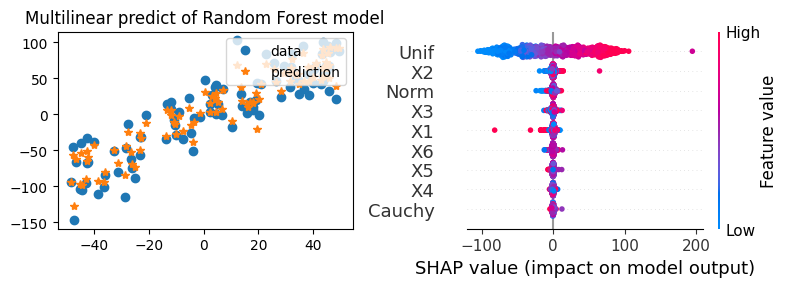

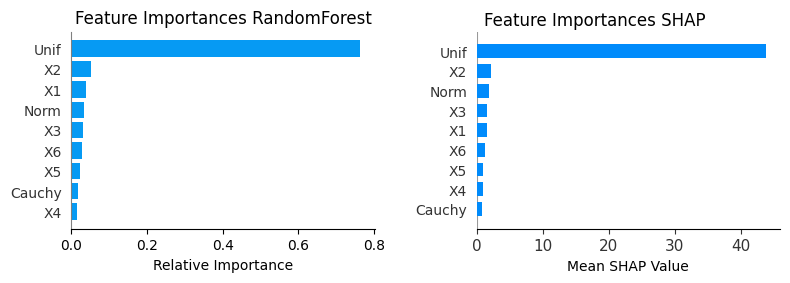

In [72]:
########################################## Visualisation 
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
plt.subplot(221)
### Visualisation data predict
x=fakes['Unif']
plt.plot (x.iloc[1:100],Y6.iloc[1:100,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(x.iloc[1:100],model.predict(X.iloc[1:100,]) , '*',label="prediction")
plt.title ("Multilinear predict of Random Forest model") # donne un titre au graphique
plt.legend(loc='upper right')
plt.subplot(222)
shap.summary_plot(shap_values, X)
## feature importance RandomForest
plt.subplot(223)
features = X.columns
plt.title('Feature Importances RandomForest')
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=10,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=10)
## feature importance SHAP
plt.subplot(2, 2, 4)
shap.summary_plot(shap_values, X, plot_type="bar",show=0,sort=True)
plt.xlabel('Mean SHAP Value',fontsize=10)
plt.yticks(fontsize=10,color ='0.2')
plt.suptitle("Feature Importances SHAP",y=0.55,x=0.75)
plt.show()
#plt.savefig("visualinear.jpg",dpi=800, quality=90, optimize=True, progressive=True)

In [78]:
############################## Shap avec Logarithme predict
Y7 = df_noisy_50['Log']
X = fakes

In [79]:
##### Random Forest model
model = RandomForestRegressor(n_estimators = 100, random_state = 0)
Score=cross_val_score(model, X , Y7, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
print(Score)
print("mean MSE: %.2E, std MSE: %.2E" %(mean_mse, std_mse))
# fit the regressor with x and y data
model.fit(X, Y7) 
print(model.feature_importances_)


[13595.00139664 13298.96708548 13110.84624728 10412.45896989
 13501.57007952 13742.33735066 22351.098338   11830.84790428
 13873.90970801 10029.16004618]
mean MSE: 1.36E+04, std MSE: 3.21E+03
[0.80496404 0.0150626  0.02864548 0.02547736 0.02659673 0.02830109
 0.01369534 0.01768524 0.03957212]


In [80]:
##### SHAP explaination
import shap
shap_values = shap.TreeExplainer(model).shap_values(X)

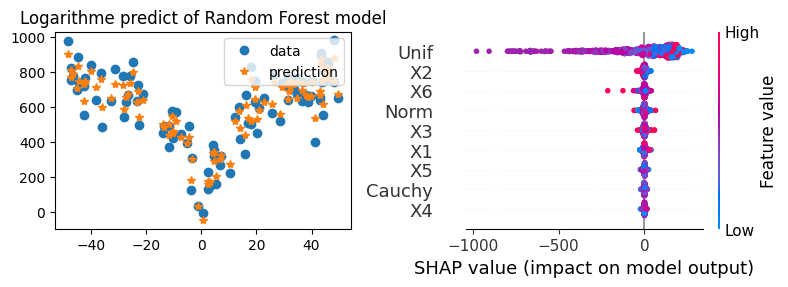

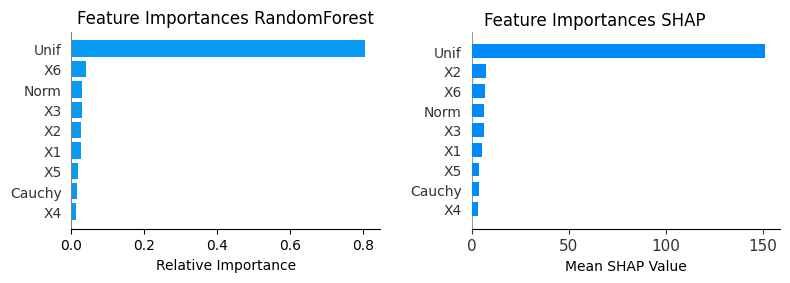

In [81]:
########################################## Visualisation 
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
plt.subplot(2, 2, 1)
### Visualisation data predict
x=fakes['Unif']
plt.plot (x.iloc[1:100],Y7.iloc[1:100,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(x.iloc[1:100],model.predict(X.iloc[1:100,]) , '*',label="prediction")
plt.title ("Logarithme predict of Random Forest model") # donne un titre au graphique
plt.legend(loc='upper right')
plt.subplot(2, 2, 2)
shap.summary_plot(shap_values, X)
## feature importance RandomForest
plt.subplot(2, 2, 3)
features = X.columns
plt.title('Feature Importances RandomForest')
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=10,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=10)
## feature importance SHAP
plt.subplot(2, 2, 4)
shap.summary_plot(shap_values, X, plot_type="bar",show=0,sort=True)
plt.xlabel('Mean SHAP Value',fontsize=10)
plt.yticks(fontsize=10,color ='0.2')
plt.suptitle("Feature Importances SHAP",y=0.55,x=0.75)
plt.show()
#plt.savefig("visualinear.jpg",dpi=800, quality=90, optimize=True, progressive=True)

In [82]:
############################## Shap avec Exponentiel predict
Y8 = df_noisy_50['Exp']
X = fakes

In [83]:
##### Random Forest model
model = RandomForestRegressor(n_estimators = 100, random_state = 0)
Score=cross_val_score(model, X , Y8, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
print(Score)
print("mean MSE: %.2E, std MSE: %.2E" %(mean_mse, std_mse))
# fit the regressor with x and y data
model.fit(X, Y8) 
print(model.feature_importances_)


[355.31884323 389.19651251 401.51072143 307.16072923 366.62713121
 356.27665047 323.65102891 370.60695852 446.0872517  430.79871034]
mean MSE: 3.75E+02, std MSE: 4.14E+01
[0.80624051 0.01587233 0.02813682 0.02948083 0.03196723 0.03071216
 0.0161216  0.01941747 0.02205105]


In [84]:
##### SHAP explaination
import shap
shap_values = shap.TreeExplainer(model).shap_values(X)

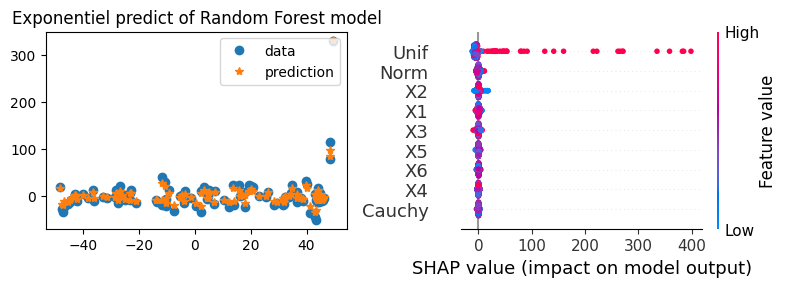

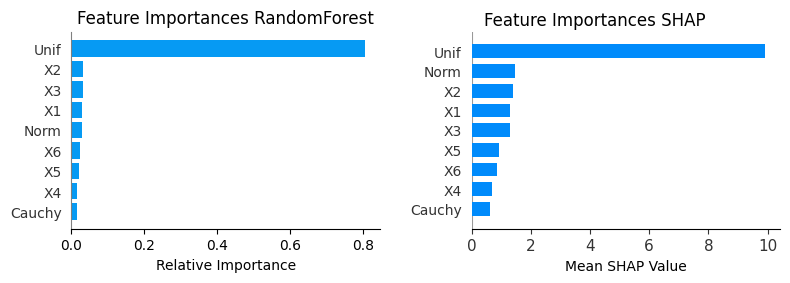

In [85]:
########################################## Visualisation 
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
plt.subplot(2, 2, 1)
### Visualisation data predict
x=fakes['Unif']
plt.plot (x.iloc[1:100],Y8.iloc[1:100,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(x.iloc[1:100],model.predict(X.iloc[1:100,]) , '*',label="prediction")
plt.title ("Exponentiel predict of Random Forest model") # donne un titre au graphique
plt.legend(loc='upper right')
plt.subplot(2, 2, 2)
shap.summary_plot(shap_values, X)
## feature importance RandomForest
plt.subplot(2, 2, 3)
features = X.columns
plt.title('Feature Importances RandomForest')
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=10,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=10)
## feature importance SHAP
plt.subplot(2, 2, 4)
shap.summary_plot(shap_values, X, plot_type="bar",show=0,sort=True)
plt.xlabel('Mean SHAP Value',fontsize=10)
plt.yticks(fontsize=10,color ='0.2')
plt.suptitle("Feature Importances SHAP",y=0.55,x=0.75)
plt.show()
#plt.savefig("visualinear.jpg",dpi=800, quality=90, optimize=True, progressive=True)

In [86]:
############################## Shap avec Sinus predict
Y9 = df_noisy_50['Sinus']
X = fakes

In [87]:
##### Random Forest model
model = RandomForestRegressor(n_estimators = 100, random_state = 0)
Score=cross_val_score(model, X , Y9, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
print(Score)
print("mean MSE: %.2E, std MSE: %.2E" %(mean_mse, std_mse))
# fit the regressor with x and y data
model.fit(X, Y9) 
print(model.feature_importances_)


[102387.66374298 115014.53704335 103772.71676478 115128.17610632
  98907.46513995  95391.75151572  91879.98922199 107009.27845704
 136657.73568373 131384.53488021]
mean MSE: 1.10E+05, std MSE: 1.41E+04
[0.42307321 0.04116879 0.09361875 0.08099825 0.10745012 0.08942167
 0.04050348 0.05173169 0.07203404]


In [88]:
##### SHAP explaination
import shap
shap_values = shap.TreeExplainer(model).shap_values(X)

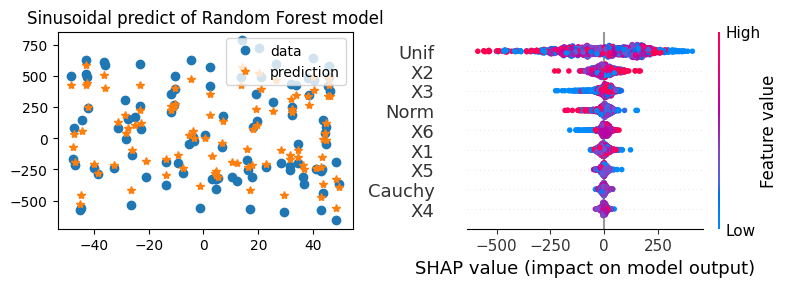

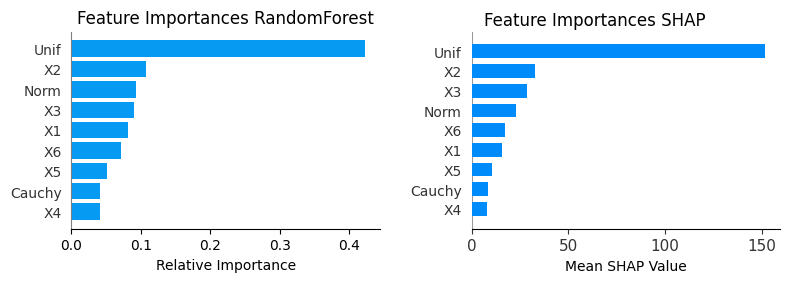

In [89]:
########################################## Visualisation 
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
plt.subplot(2, 2, 1)
### Visualisation data predict
x=fakes['Unif']
plt.plot (x.iloc[1:100],Y9.iloc[1:100,],'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(x.iloc[1:100],model.predict(X.iloc[1:100,]) , '*',label="prediction")
plt.title ("Sinusoidal predict of Random Forest model") # donne un titre au graphique
plt.legend(loc='upper right')
plt.subplot(2, 2, 2)
shap.summary_plot(shap_values, X)
## feature importance RandomForest
plt.subplot(2, 2, 3)
features = X.columns
plt.title('Feature Importances RandomForest')
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=10,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=10)
plt.subplot(2, 2, 4)
shap.summary_plot(shap_values, X, plot_type="bar",show=0,sort=True)
plt.xlabel('Mean SHAP Value',fontsize=10)
plt.yticks(fontsize=10,color ='0.2')
plt.suptitle("Feature Importances SHAP",y=0.55,x=0.75)
plt.show()
#plt.savefig("visualinear.jpg",dpi=800, quality=90, optimize=True, progressive=True)

In [90]:
## add 100% of gaussian noise to my data 
# x is my training data
# mu is the mean
# std is the standard deviation
import numpy as np
def gaussian_noise(x,mu,std):
    mu=0.0
    std = 1 * np.std(x) # for 100% Gaussian noise   
    noise = np.random.normal(mu, std, size = x.shape)
    x_noisy = x + noise
    return x_noisy 

In [91]:
mu=0.0
std = 1 * np.std(df) # for 100% Gaussian noise   
df_noisy_100=gaussian_noise(df,0.0,std)
df_noisy_100.head(10)

,Linear,Polynom2,Polynom3,Polynom4,Polynom5,Multilinear,Log,Exp,Sinus
0,515.655212,-8.466806,-181.163392,-102.165822,-493.893155,76.514115,183.545743,-50.743804,465.678340
1,-2.187264,208.708750,47.015719,488.304130,-98.522854,-0.758883,648.841779,41.401656,78.707284
2,-203.470048,-84.607888,-171.862462,775.953687,146.020217,-7.225334,637.183879,-63.170557,223.622704
3,-468.845120,-12.934887,-289.806931,478.236250,30.402588,-25.159953,506.020598,17.923268,-47.232947
4,-323.347759,103.657954,-90.946108,53.750113,281.209495,137.209012,311.760237,28.686749,368.636406
5,-204.811650,-89.342286,43.364618,239.220723,135.157445,100.159088,600.356860,-33.259298,683.884686
6,-66.830739,146.223819,-14.855072,91.406516,222.005292,-18.375789,823.101618,-71.104395,228.146183
7,358.716642,155.352753,88.481360,756.668107,384.622644,-76.651380,517.592796,-20.116176,402.822976
8,-381.767971,31.144718,109.100350,996.736461,198.991649,145.157952,908.912551,-20.253932,604.483011
9,-415.519823,441.242587,-405.253417,449.448190,-50.102706,111.778915,1201.944349,30.898795,214.179256


In [92]:
####################### Shap avec Linear predict
Y1 = df_noisy_100['Linear']
X = fakes

In [93]:
##### Random Forest model
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators = 100, random_state = 0)
Score=cross_val_score(model, X , Y1, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
print(Score)
print("mean MSE: %.2E, std MSE: %.2E" %(mean_mse, std_mse))
# fit the regressor with x and y data
model.fit(X, Y1) 
print(model.feature_importances_)


[104910.04242841  92094.22581656 110648.53889756  86632.89602082
 104999.21553772  85109.42242415  75850.18334757  92684.89022081
  77909.04312621  99218.44089861]
mean MSE: 9.30E+04, std MSE: 1.12E+04
[0.55882058 0.03080291 0.05757966 0.07167733 0.06793264 0.06767681
 0.0322142  0.04696779 0.06632807]


In [94]:
##### SHAP explaination
import shap
shap_values = shap.TreeExplainer(model).shap_values(X)

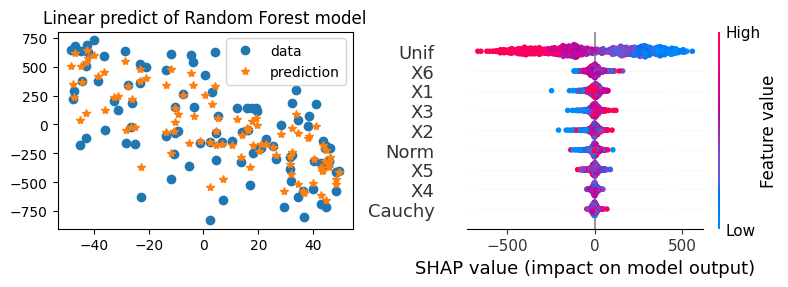

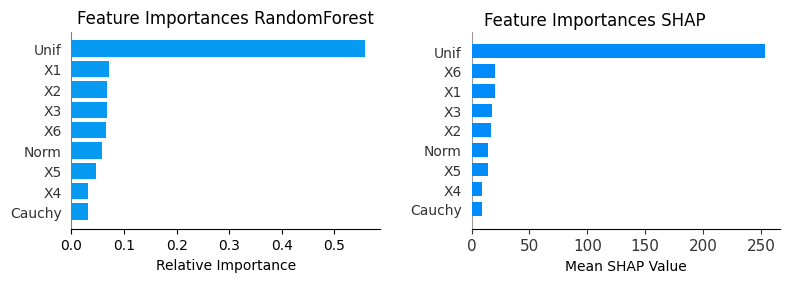

In [96]:
#### Visualisation 
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
plt.subplot(221)
### Visualisation data predict
x=fakes['Unif']
plt.plot (x.iloc[1:100],Y1.iloc[1:100,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(x.iloc[1:100],model.predict(X.iloc[1:100,]) , '*',label="prediction")
plt.title ("Linear predict of Random Forest model") # donne un titre au graphique
plt.legend(loc='upper right')
plt.subplot(2, 2, 2)
shap.summary_plot(shap_values, X)             
## feature importance RandomForest
plt.subplot(223)
features = X.columns
plt.title('Feature Importances RandomForest')
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=10,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=10) 
## feature importance SHAP
plt.subplot(224)
shap.summary_plot(shap_values, X, plot_type="bar",show=0,sort=True) 
plt.xlabel('Mean SHAP Value',fontsize=10)
plt.yticks(fontsize=10,color ='0.2')
plt.suptitle("Feature Importances SHAP",y=0.55,x=0.75)
plt.show()
#plt.savefig("visualinear.jpg",dpi=800, quality=90, optimize=True, progressive=True)

In [97]:
##################### Shap avec Quadratic predict
Y2 = df_noisy_100['Polynom2']
X = fakes

In [98]:
##### Random Forest model
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators = 100, random_state = 0)
Score=cross_val_score(model, X , Y2, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
print(Score)
print("mean MSE: %.2E, std MSE: %.2E" %(mean_mse, std_mse))
# fit the regressor with x and y data
model.fit(X, Y2) 
print(model.feature_importances_)

[20654.43523231 26214.68669755 23955.10790017 26961.03390126
 33267.66741592 26115.13524491 24238.57685536 30390.39595562
 29589.70575014 25033.08229498]
mean MSE: 2.66E+04, std MSE: 3.44E+03
[0.58803213 0.03641446 0.057236   0.05812991 0.06496095 0.06401329
 0.03215773 0.03861114 0.06044441]


In [99]:
##### SHAP explaination
import shap
shap_values = shap.TreeExplainer(model).shap_values(X)

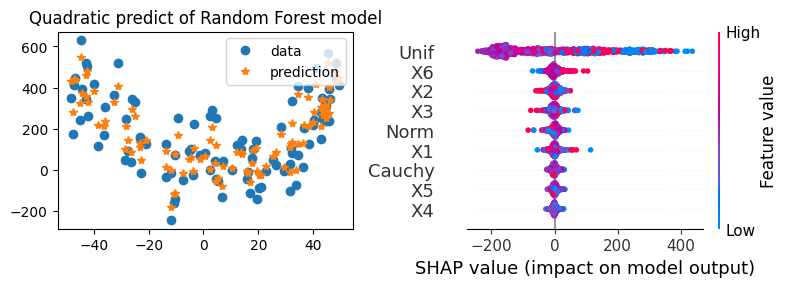

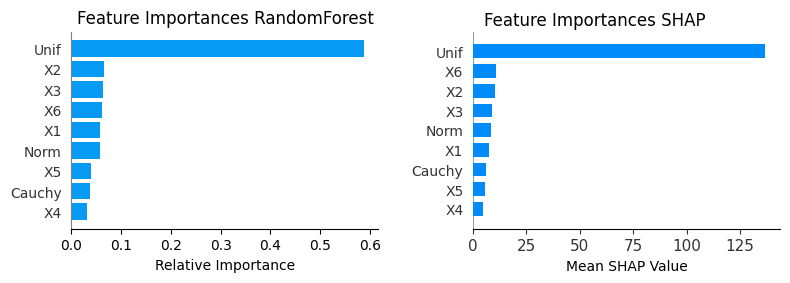

In [101]:
#### Visualisation 
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
plt.subplot(221)
### Visualisation data predict
x=fakes['Unif']
plt.plot (x.iloc[1:100],Y2.iloc[1:100,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(x.iloc[1:100],model.predict(X.iloc[1:100,]) , '*',label="prediction")
plt.title ("Quadratic predict of Random Forest model") # donne un titre au graphique
plt.legend(loc='upper right')
plt.subplot(222)
shap.summary_plot(shap_values, X)
## feature importance RandomForest
plt.subplot(223)
features = X.columns
plt.title('Feature Importances RandomForest')
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=10,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=10)
## feature importance SHAP
plt.subplot(224)
shap.summary_plot(shap_values, X, plot_type="bar",show=0,sort=True)
plt.xlabel('Mean SHAP Value',fontsize=10)
plt.yticks(fontsize=10,color ='0.2')
plt.suptitle("Feature Importances SHAP",y=0.55,x=0.75)
plt.show()
#plt.savefig("visualinear.jpg",dpi=800, quality=90, optimize=True, progressive=True)

In [102]:
############################## Shap avec Cubic predict
Y3 = df_noisy_100['Polynom3']
X = fakes

In [103]:
##### Random Forest model
model = RandomForestRegressor(n_estimators = 100, random_state = 0)
Score=cross_val_score(model, X , Y3, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
print(Score)
print("mean MSE: %.2E, std MSE: %.2E" %(mean_mse, std_mse))
# fit the regressor with x and y data
model.fit(X, Y3) 
print(model.feature_importances_)


[51092.22622837 86410.83584977 71314.21099984 57652.17503865
 58768.72442787 76236.76041909 69253.64919002 59091.98548078
 81813.34637931 65689.47774193]
mean MSE: 6.77E+04, std MSE: 1.08E+04
[0.58394146 0.03455203 0.0575475  0.0622184  0.06494651 0.06573237
 0.03079351 0.04237769 0.05789053]


In [104]:
##### SHAP explaination
import shap
shap_values = shap.TreeExplainer(model).shap_values(X)

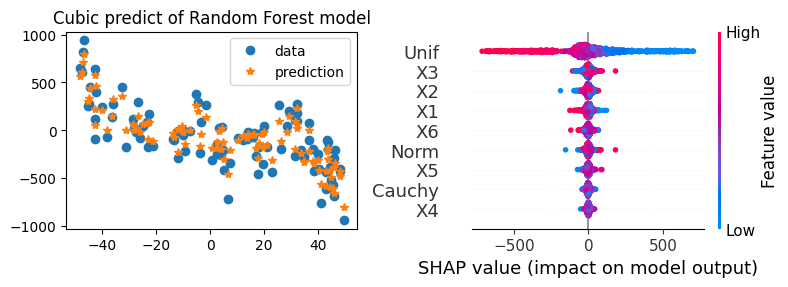

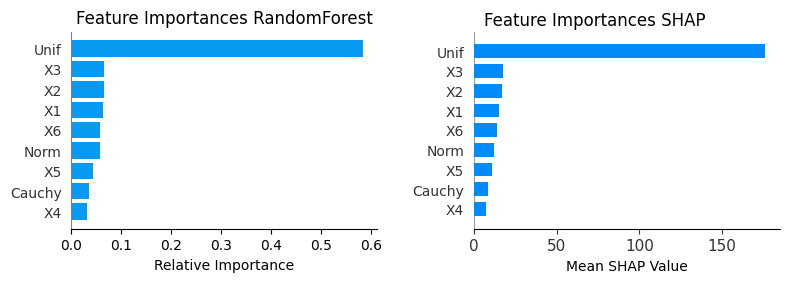

In [105]:
#### Visualisation 
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
plt.subplot(2, 2, 1)
### Visualisation data predict
x=fakes['Unif']
plt.plot (x.iloc[1:100],Y3.iloc[1:100,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(x.iloc[1:100],model.predict(X.iloc[1:100,]) , '*',label="prediction")
plt.title ("Cubic predict of Random Forest model") # donne un titre au graphique
plt.legend(loc='upper right')
plt.subplot(2, 2, 2)
shap.summary_plot(shap_values, X)
## feature importance RandomForest
plt.subplot(2, 2, 3)
features = X.columns
plt.title('Feature Importances RandomForest')
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=10,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=10)
## feature importance SHAP
plt.subplot(2, 2, 4)
shap.summary_plot(shap_values, X, plot_type="bar",show=0,sort=True)
plt.xlabel('Mean SHAP Value',fontsize=10)
plt.yticks(fontsize=10,color ='0.2')
plt.suptitle("Feature Importances SHAP",y=0.55,x=0.75)
plt.show()
#plt.savefig("visualinear.jpg",dpi=800, quality=90, optimize=True, progressive=True)

In [106]:
########################## Shap avec Quartic predict
Y4= df_noisy_100['Polynom4']
X = fakes

In [110]:
##### Random Forest model
model = RandomForestRegressor(n_estimators = 100, random_state = 0)
Score=cross_val_score(model, X , Y4, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
print(Score)
print("mean MSE: %.2E, std MSE: %.2E" %(mean_mse, std_mse))
# fit the regressor with x and y data
model.fit(X, Y4) 
print(model.feature_importances_)


[ 97849.76612029  82305.20362049  97237.64967759 106711.00066562
 119345.86810832 115159.71177946  96721.34565247  82332.464817
  94556.76521126 123520.86625183]
mean MSE: 1.02E+05, std MSE: 1.36E+04
[0.57422872 0.0330845  0.05864621 0.06272066 0.07649274 0.06923779
 0.03249677 0.04073535 0.05235727]


In [108]:
##### SHAP explaination
import shap
shap_values = shap.TreeExplainer(model).shap_values(X)

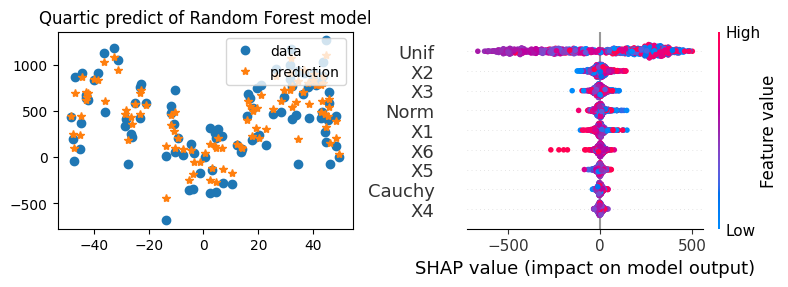

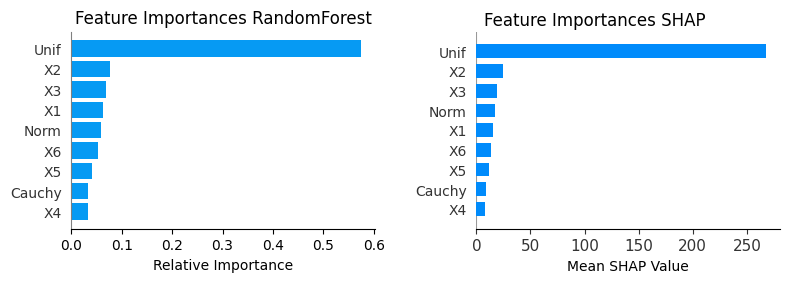

In [109]:
########################################## Visualisation 
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
plt.subplot(2, 2, 1)
### Visualisation data predict
x=fakes['Unif']
plt.plot (x.iloc[1:100],Y4.iloc[1:100,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(x.iloc[1:100],model.predict(X.iloc[1:100,]) , '*',label="prediction")
plt.title ("Quartic predict of Random Forest model") # donne un titre au graphique
plt.legend(loc='upper right')
plt.subplot(2, 2, 2)
shap.summary_plot(shap_values, X)
## feature importance RandomForest
plt.subplot(2, 2, 3)
features = X.columns
plt.title('Feature Importances RandomForest')
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=10,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=10)
## feature importance SHAP
plt.subplot(2, 2, 4)
shap.summary_plot(shap_values, X, plot_type="bar",show=0,sort=True)
plt.xlabel('Mean SHAP Value',fontsize=10)
plt.yticks(fontsize=10,color ='0.2')
plt.suptitle("Feature Importances SHAP",y=0.55,x=0.75)
plt.show()
#plt.savefig("visualinear.jpg",dpi=800, quality=90, optimize=True, progressive=True)

In [112]:
############################## Shap avec Quintic predict
Y5 = df_noisy_100['Polynom5']
X = fakes

In [113]:
##### Random Forest model
model = RandomForestRegressor(n_estimators = 100, random_state = 0)
Score=cross_val_score(model, X , Y5, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
print(Score)
print("mean MSE: %.2E, std MSE: %.2E" %(mean_mse, std_mse))
# fit the regressor with x and y data
model.fit(X, Y5) 
print(model.feature_importances_)


[37253.34905713 38640.32521723 33440.78424305 40233.11906937
 48182.21981769 37393.65518468 40152.80715651 37069.31982605
 36993.76392203 45515.1816128 ]
mean MSE: 3.95E+04, std MSE: 4.14E+03
[0.56630684 0.0378878  0.06640273 0.06477024 0.06780125 0.07057959
 0.03635782 0.03781639 0.05207735]


In [114]:
##### SHAP explaination
import shap
shap_values = shap.TreeExplainer(model).shap_values(X)

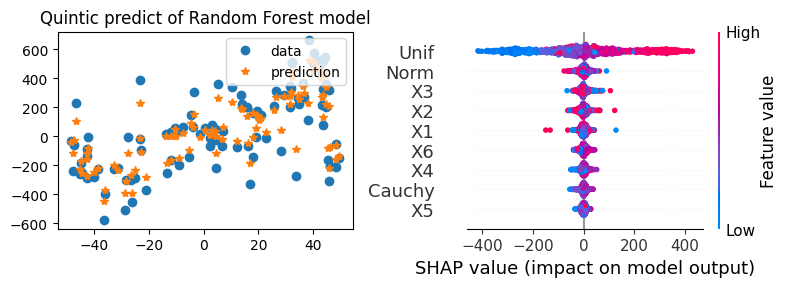

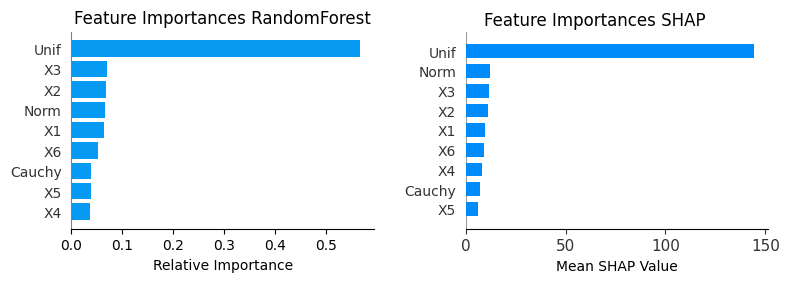

In [115]:
########################################## Visualisation 
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
plt.subplot(2, 2, 1)
### Visualisation data predict
x=fakes['Unif']
plt.plot (x.iloc[1:100],Y5.iloc[1:100,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(x.iloc[1:100],model.predict(X.iloc[1:100,]) , '*',label="prediction")
plt.title ("Quintic predict of Random Forest model") # donne un titre au graphique
plt.legend(loc='upper right')
plt.subplot(2, 2, 2)
shap.summary_plot(shap_values, X)
## feature importance RandomForest
plt.subplot(2, 2, 3)
features = X.columns
plt.title('Feature Importances RandomForest')
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=10,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=10)
## feature importance SHAP
plt.subplot(2, 2, 4)
shap.summary_plot(shap_values, X, plot_type="bar",show=0,sort=True)
plt.xlabel('Mean SHAP Value',fontsize=10)
plt.yticks(fontsize=10,color ='0.2')
plt.suptitle("Feature Importances SHAP",y=0.55,x=0.75)
plt.show()
#plt.savefig("visualinear.jpg",dpi=800, quality=90, optimize=True, progressive=True)

In [116]:
############################## Shap avec Multilinear predict
Y6 = df_noisy_100['Multilinear']
X = fakes

In [117]:
##### Random Forest model
model = RandomForestRegressor(n_estimators = 100, random_state = 0)
Score=cross_val_score(model, X , Y6, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
print(Score)
print("mean MSE: %.2E, std MSE: %.2E" %(mean_mse, std_mse))
# fit the regressor with x and y data
model.fit(X, Y6) 
print(model.feature_importances_)


[3736.10282011 3175.12491439 3411.08865863 5478.20401042 3424.3419886
 3241.02822142 3385.25840685 3321.61115881 3304.25689106 3006.67954123]
mean MSE: 3.55E+03, std MSE: 6.68E+02
[0.52860996 0.03618562 0.06148645 0.08518512 0.07052457 0.07247634
 0.03639232 0.05887615 0.05026348]


In [118]:
##### SHAP explaination
import shap
shap_values = shap.TreeExplainer(model).shap_values(X)

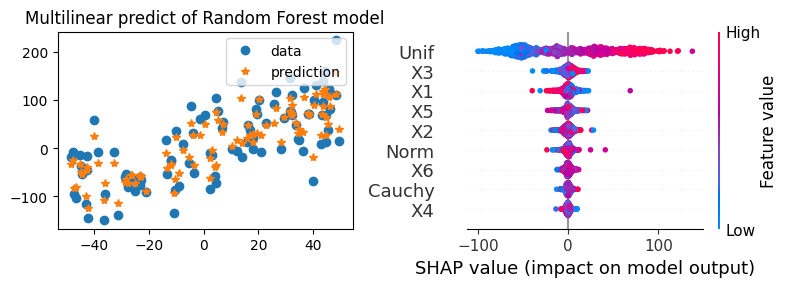

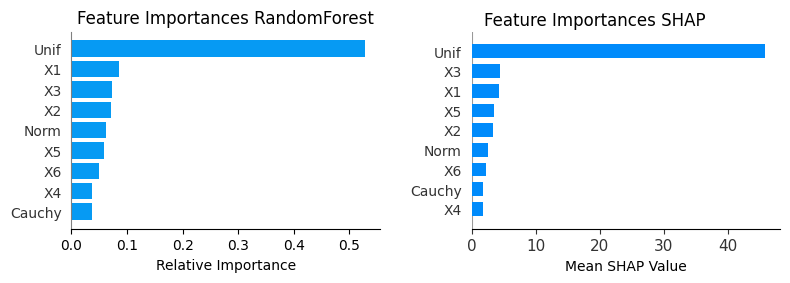

In [119]:
########################################## Visualisation 
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
plt.subplot(2, 2, 1)
### Visualisation data predict
x=fakes['Unif']
plt.plot (x.iloc[1:100],Y6.iloc[1:100,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(x.iloc[1:100],model.predict(X.iloc[1:100,]) , '*',label="prediction")
plt.title ("Multilinear predict of Random Forest model") # donne un titre au graphique
plt.legend(loc='upper right')
plt.subplot(2, 2, 2)
shap.summary_plot(shap_values, X)
## feature importance RandomForest
plt.subplot(2, 2, 3)
features = X.columns
plt.title('Feature Importances RandomForest')
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=10,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=10)
## feature importance SHAP
plt.subplot(2, 2, 4)
shap.summary_plot(shap_values, X, plot_type="bar",show=0,sort=True)
plt.xlabel('Mean SHAP Value',fontsize=10)
plt.yticks(fontsize=10,color ='0.2')
plt.suptitle("Feature Importances SHAP",y=0.55,x=0.75)
plt.show()
#plt.savefig("visualinear.jpg",dpi=800, quality=90, optimize=True, progressive=True)

In [120]:
############################## Shap avec Logarithme predict
Y7 = df_noisy_100['Log']
X = fakes

In [121]:
##### Random Forest model
model = RandomForestRegressor(n_estimators = 100, random_state = 0)
Score=cross_val_score(model, X , Y7, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
print(Score)
print("mean MSE: %.2E, std MSE: %.2E" %(mean_mse, std_mse))
# fit the regressor with x and y data
model.fit(X, Y7) 
print(model.feature_importances_)


[54561.83030398 57873.70837641 48371.23081982 59854.5094602
 54910.29587133 57437.23555557 60186.68578914 54429.85161318
 61304.24745058 43985.75565727]
mean MSE: 5.53E+04, std MSE: 5.19E+03
[0.56014706 0.03067815 0.05540885 0.06492026 0.06278243 0.06960436
 0.03530382 0.04915797 0.07199711]


In [122]:
##### SHAP explaination
import shap
shap_values = shap.TreeExplainer(model).shap_values(X)

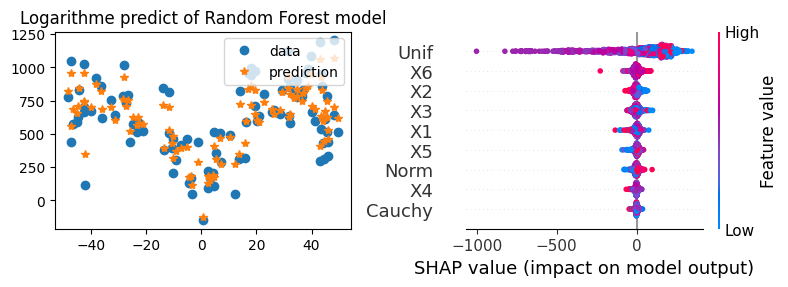

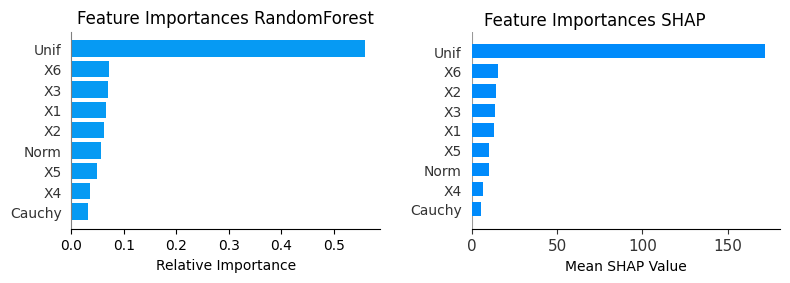

In [123]:
########################################## Visualisation 
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
plt.subplot(2, 2, 1)
### Visualisation data predict
x=fakes['Unif']
plt.plot (x.iloc[1:100],Y7.iloc[1:100,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(x.iloc[1:100],model.predict(X.iloc[1:100,]) , '*',label="prediction")
plt.title ("Logarithme predict of Random Forest model") # donne un titre au graphique
plt.legend(loc='upper right')
plt.subplot(2, 2, 2)
shap.summary_plot(shap_values, X)
## feature importance RandomForest
plt.subplot(2, 2, 3)
features = X.columns
plt.title('Feature Importances RandomForest')
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=10,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=10)
## feature importance SHAP
plt.subplot(2, 2, 4)
shap.summary_plot(shap_values, X, plot_type="bar",show=0,sort=True)
plt.xlabel('Mean SHAP Value',fontsize=10)
plt.yticks(fontsize=10,color ='0.2')
plt.suptitle("Feature Importances SHAP",y=0.55,x=0.75)
plt.show()
#plt.savefig("visualinear.jpg",dpi=800, quality=90, optimize=True, progressive=True)

In [124]:
############################## Shap avec Exponentiel predict
Y8 = df_noisy_100['Exp']
X = fakes

In [125]:
##### Random Forest model
model = RandomForestRegressor(n_estimators = 100, random_state = 0)
Score=cross_val_score(model, X , Y8, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
print(Score)
print("mean MSE: %.2E, std MSE: %.2E" %(mean_mse, std_mse))
# fit the regressor with x and y data
model.fit(X, Y8) 
print(model.feature_importances_)


[1362.45375418 1217.14659707 1593.30544506 1366.17513688 1381.69537001
 1417.63790862 1268.55234495 1534.17916293 1551.70715813 1579.14157333]
mean MSE: 1.43E+03, std MSE: 1.25E+02
[0.5428778  0.03597905 0.05971133 0.06514246 0.07345386 0.0895336
 0.03548998 0.04120949 0.05660243]


In [126]:
#### SHAP explaination
import shap
shap_values = shap.TreeExplainer(model).shap_values(X)

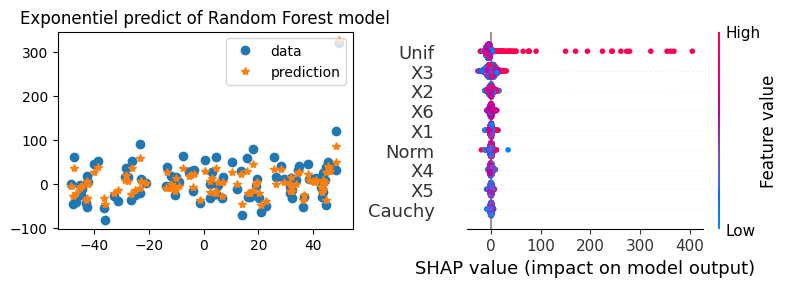

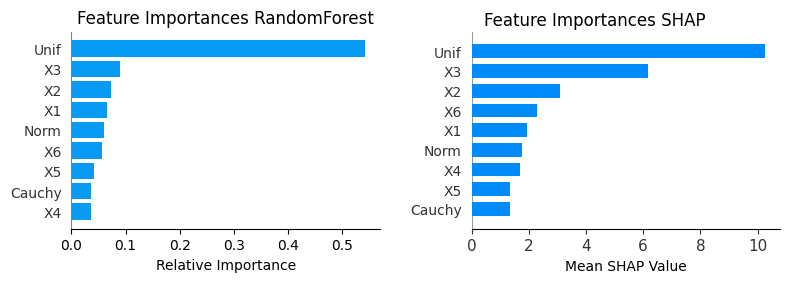

In [127]:
########################################## Visualisation 
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
plt.subplot(2, 2, 1)
### Visualisation data predict
x=fakes['Unif']
plt.plot (x.iloc[1:100],Y8.iloc[1:100,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(x.iloc[1:100],model.predict(X.iloc[1:100,]) , '*',label="prediction")
plt.title ("Exponentiel predict of Random Forest model") # donne un titre au graphique
plt.legend(loc='upper right')
plt.subplot(2, 2, 2)
shap.summary_plot(shap_values, X)
## feature importance RandomForest
plt.subplot(2, 2, 3)
features = X.columns
plt.title('Feature Importances RandomForest')
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=10,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=10)
## feature importance SHAP
plt.subplot(2, 2, 4)
shap.summary_plot(shap_values, X, plot_type="bar",show=0,sort=True)
plt.xlabel('Mean SHAP Value',fontsize=10)
plt.yticks(fontsize=10,color ='0.2')
plt.suptitle("Feature Importances SHAP",y=0.55,x=0.75)
plt.show()
#plt.savefig("visualinear.jpg",dpi=800, quality=90, optimize=True, progressive=True)

In [128]:
############################## Shap avec Sinus predict
Y9 = df_noisy_100['Sinus']
X = fakes

In [129]:
##### Random Forest model
model = RandomForestRegressor(n_estimators = 100, random_state = 0)
Score=cross_val_score(model, X , Y9, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
print(Score)
print("mean MSE: %.2E, std MSE: %.2E" %(mean_mse, std_mse))
# fit the regressor with x and y data
model.fit(X, Y9) 
print(model.feature_importances_)


[219713.96710012 225150.39312121 198630.21774949 234306.18721158
 247700.44020484 189768.65707286 211240.11337494 193450.36352978
 313329.71578563 187439.50114418]
mean MSE: 2.22E+05, std MSE: 3.59E+04
[0.28102213 0.05803366 0.09333986 0.10487525 0.12927814 0.11049468
 0.05511771 0.06801532 0.09982324]


In [130]:
#### SHAP explaination
import shap
shap_values = shap.TreeExplainer(model).shap_values(X)

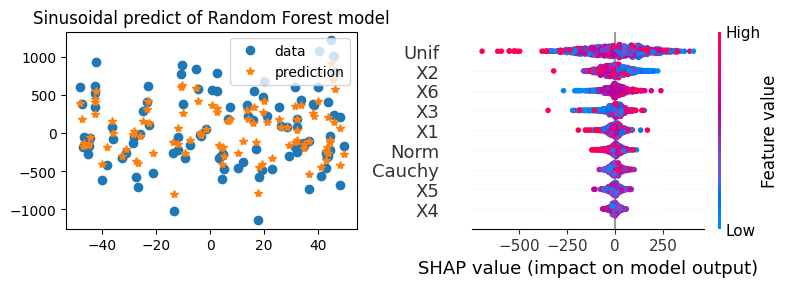

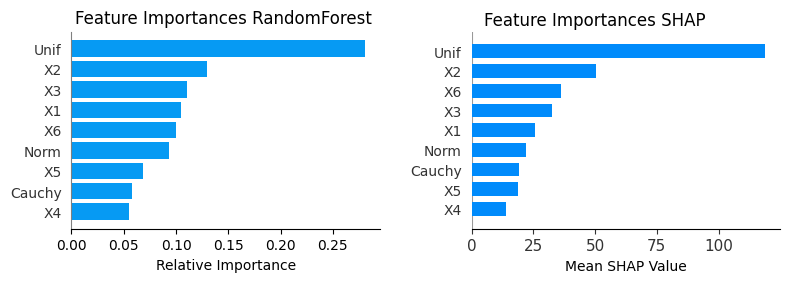

In [131]:
########################################## Visualisation 
import matplotlib.pyplot as plt
import seaborn as sns
importances = model.feature_importances_
indices = np.argsort(importances)
plt.subplot(2, 2, 1)
### Visualisation data predict
x=fakes['Unif']
plt.plot (x.iloc[1:100],Y9.iloc[1:100,],'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(x.iloc[1:100],model.predict(X.iloc[1:100,]) , '*',label="prediction")
plt.title ("Sinusoidal predict of Random Forest model") # donne un titre au graphique
plt.legend(loc='upper right')
plt.subplot(2, 2, 2)
shap.summary_plot(shap_values, X)
## feature importance RandomForest
plt.subplot(2, 2, 3)
features = X.columns
plt.title('Feature Importances RandomForest ')
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=10,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=10)
plt.subplot(2, 2, 4)
shap.summary_plot(shap_values, X, plot_type="bar", show=0,sort=True)
plt.xlabel('Mean SHAP Value',fontsize=10)
plt.yticks(fontsize=10,color ='0.2')
plt.suptitle("Feature Importances SHAP",y=0.55,x=0.75)
plt.show()
#plt.savefig("visualinear.jpg",dpi=800, quality=90, optimize=True, progressive=True)